In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
from pathlib import Path
from PIL import Image
import io

warnings.filterwarnings('ignore')

# Настройки для визуализации
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# Анализ финансовых потерь от невыкупа заказов

Этот блокнот анализирует потери от невыкупленных заказов по различным группирующим признакам:
- lead_region (регион лида)
- price_group (ценовая группа)
- delivery_group (группа доставки)

Цель: определить основные источники потерь для финансового анализа

In [ ]:
# Создаем подпапку для результатов анализа
results_folder = './loss_analysis_results'
Path(results_folder).mkdir(exist_ok=True)

print(f"📁 Подпапка для результатов создана: {results_folder}")
print(f"✓ Все результаты будут сохранены в этой папке")

📁 Подпапка для результатов создана: ./loss_analysis_results
✓ Все результаты будут сохранены в этой папке


## 1. Загрузка и исследование данных

In [ ]:
# Загрузим данные
file_path = '../data_preparation/data/clean/clean_data_with_regions copy.xlsx'
df = pd.read_excel(file_path)

print(f"Размер датасета: {df.shape}")
print(f"\nКолонки в датасете:")
print(df.columns.tolist())
print(f"\nТипы данных:")
print(df.dtypes)
print(f"\nПервые строки:")
print(df.head())

Размер датасета: (17966, 56)

Колонки в датасете:
['lead_id', 'sale_ts', 'sale_date', 'buyout_flag', 'handed_to_delivery_ts', 'issued_or_pvz_ts', 'received_ts', 'rejected_ts', 'returned_ts', 'days_to_outcome', 'closed_ts', 'lead_price', 'lead_responsible_user_id', 'lead_tags', 'lead_yclid', 'lead_Служба доставки', 'lead_Вид оплаты', 'lead_Проблема', 'lead_Состав заказа', 'lead_Оплата МОП', 'lead_Дата получения денег на Р/С', 'contact_id', 'contact_Город', 'contact_LTV', 'contact_Число сделок', 'lead_Источник', 'lead_Условный отказ', 'lead_Тариф Доставки', 'lead_Скидка', 'lead_Квалификация лида', 'lead_Дата создания сделки', 'lead_Дата перехода в Сборку', 'has_yclid', 'is_paid_mop', 'is_repeat_client', 'has_promo', 'lead_source_category', 'is_yur', 'has_маска', 'has_наколенник', 'has_бандаж_шейный', 'has_повязка', 'has_напульсник', 'has_обувь', 'has_подушка', 'has_матрас', 'has_пояс', 'has_аксессуары', 'has_крем', 'n_product_categories', 'has_постельное', 'has_бады', 'delivery_days', 'd

In [ ]:
# Проверим ключевые колонки для анализа
print("Информация о ключевых колонках:")
print(f"\nbuyout_flag: {df['buyout_flag'].unique()}")
print(f"buyout_flag value_counts:\n{df['buyout_flag'].value_counts()}")
print(f"\nlead_price статистика:\n{df['lead_price'].describe()}")
print(f"\nlead_region уникальных значений: {df['lead_region'].nunique()}")
print(f"Примеры lead_region: {df['lead_region'].unique()[:10]}")
print(f"\nprice_group уникальных значений: {df['price_group'].nunique()}")
print(f"Примеры price_group: {df['price_group'].unique()[:10]}")
print(f"\ndelivery_group уникальных значений: {df['delivery_group'].nunique()}")
print(f"Примеры delivery_group: {df['delivery_group'].unique()[:10]}")

Информация о ключевых колонках:

buyout_flag: [1 0]
buyout_flag value_counts:
buyout_flag
1    14882
0     3084
Name: count, dtype: int64

lead_price статистика:
count     17966.000000
mean      11553.658132
std       10257.629364
min           0.000000
25%        6470.000000
50%        8925.500000
75%       14390.000000
max      413432.000000
Name: lead_price, dtype: float64

lead_region уникальных значений: 88
Примеры lead_region: <StringArray>
[ 'Ставропольский край',               'Москва',      'Приморский край',
  'Саратовская область', 'Свердловская область',     'Амурская область',
   'Забайкальский край',   'Ростовская область',       'Алтайский край',
    'Калужская область']
Length: 10, dtype: str

price_group уникальных значений: 4
Примеры price_group: <StringArray>
['до 5к', '5к-15к', '20к+', '15к-20к']
Length: 4, dtype: str

delivery_group уникальных значений: 4
Примеры delivery_group: <StringArray>
['средняя', 'быстрая', 'очень долгая', 'долгая', nan]
Length: 5, dtype: s

In [ ]:
# Проверим наличие boolean колонок с товарами
product_columns = ['has_маска', 'has_наколенник', 'has_бандаж_шейный', 
                   'has_повязка', 'has_напульсник', 'has_обувь', 
                   'has_подушка', 'has_матрас', 'has_постельное', 
                   'has_пояс', 'has_аксессуары', 'has_крем', 'has_бады']

print("✓ Проверка boolean колонок товаров:")
print(f"Всего товарных категорий: {len(product_columns)}")

# Найдём какие колонки существуют в данных
existing_cols = [col for col in product_columns if col in df.columns]
missing_cols = [col for col in product_columns if col not in df.columns]

print(f"Найдено колонок: {len(existing_cols)}")
if existing_cols:
    for col in existing_cols:
        print(f"  - {col}: {df[col].dtype}, значения: {df[col].unique()}")

if missing_cols:
    print(f"\nНЕ найдено колонок: {missing_cols}")

print(f"\nВсе ли товарные колонки есть: {len(missing_cols) == 0}")

✓ Проверка boolean колонок товаров:
Всего товарных категорий: 13
Найдено колонок: 13
  - has_маска: bool, значения: [ True False]
  - has_наколенник: bool, значения: [False  True]
  - has_бандаж_шейный: bool, значения: [False  True]
  - has_повязка: bool, значения: [False  True]
  - has_напульсник: bool, значения: [False  True]
  - has_обувь: bool, значения: [False  True]
  - has_подушка: bool, значения: [False  True]
  - has_матрас: bool, значения: [False  True]
  - has_постельное: bool, значения: [False  True]
  - has_пояс: bool, значения: [False  True]
  - has_аксессуары: bool, значения: [False  True]
  - has_крем: bool, значения: [False  True]
  - has_бады: bool, значения: [False  True]

Все ли товарные колонки есть: True


## 2. Подготовка данных и расчет потерь

In [ ]:
# Определим потери: для невыкупленных заказов (buyout_flag = 0 или False) потеря = lead_price
# Создадим новую колонку для потерь
df['loss'] = 0.0
df.loc[df['buyout_flag'] == 0, 'loss'] = df.loc[df['buyout_flag'] == 0, 'lead_price']

# Альтернативный способ (на случай если используются булевы значения)
if df['buyout_flag'].dtype == bool:
    df.loc[~df['buyout_flag'], 'loss'] = df.loc[~df['buyout_flag'], 'lead_price']

print("Статистика по потерям:")
print(f"Всего заказов: {len(df)}")
print(f"Невыкупленных заказов: {(df['buyout_flag'] == 0).sum()}")
print(f"Выкупленных заказов: {(df['buyout_flag'] == 1).sum()}")
print(f"\nОбщие потери: {df['loss'].sum():,.0f}")
print(f"Средняя потеря на невыкупленный заказ: {df[df['loss'] > 0]['loss'].mean():,.0f}")
print(f"Максимальная потеря: {df['loss'].max():,.0f}")

Статистика по потерям:
Всего заказов: 17966
Невыкупленных заказов: 3084
Выкупленных заказов: 14882

Общие потери: 35,952,479
Средняя потеря на невыкупленный заказ: 11,742
Максимальная потеря: 90,650


## 3. Анализ потерь по регионам (lead_region)

In [ ]:
# Анализ потерь по регионам
loss_by_region = df.groupby('lead_region').agg({
    'loss': ['sum', 'mean', 'count'],
    'lead_price': 'sum'
}).round(2)

loss_by_region.columns = ['Total Loss', 'Avg Loss per Order', 'Non-buyout Orders', 'Total Order Value']

# Добавим процент выкупа
region_stats = df.groupby('lead_region').agg({
    'buyout_flag': lambda x: (x == 1).sum()
}).rename(columns={'buyout_flag': 'buyout_count'})

loss_by_region['Buyout Rate %'] = (region_stats['buyout_count'] / df.groupby('lead_region').size() * 100).round(2)
loss_by_region = loss_by_region.sort_values('Total Loss', ascending=False)

print("Потери по регионам (lead_region):")
print(loss_by_region)
print(f"\nТоп-5 регионов по потерям:")
print(loss_by_region.head())

Потери по регионам (lead_region):
                                          Total Loss  Avg Loss per Order  \
lead_region                                                                
Москва                                     3814128.0             1649.00   
Московская область                         2048045.0             1590.10   
Краснодарский край                         1734856.0             1994.09   
Санкт-Петербург                            1416391.0             1539.56   
Свердловская область                       1355227.0             2293.11   
Ростовская область                          945102.0             2192.81   
Челябинская область                         886751.0             2178.75   
Красноярский край                           886022.0             2362.73   
Иркутская область                           819974.0             2523.00   
Башкортостан                                754416.0             2143.23   
Ленинградская область                       728827.0  

## 4. Анализ потерь по ценовым группам (price_group)

In [ ]:
# Анализ потерь по ценовым группам
loss_by_price_group = df.groupby('price_group').agg({
    'loss': ['sum', 'mean', 'count'],
    'lead_price': 'sum'
}).round(2)

loss_by_price_group.columns = ['Total Loss', 'Avg Loss per Order', 'Non-buyout Orders', 'Total Order Value']

# Добавим процент выкупа
price_group_stats = df.groupby('price_group').agg({
    'buyout_flag': lambda x: (x == 1).sum()
}).rename(columns={'buyout_flag': 'buyout_count'})

loss_by_price_group['Buyout Rate %'] = (price_group_stats['buyout_count'] / df.groupby('price_group').size() * 100).round(2)
loss_by_price_group = loss_by_price_group.sort_values('Total Loss', ascending=False)

print("Потери по ценовым группам (price_group):")
print(loss_by_price_group)
print(f"\nТоп-5 ценовых групп по потерям:")
print(loss_by_price_group.head())

Потери по ценовым группам (price_group):
             Total Loss  Avg Loss per Order  Non-buyout Orders  \
price_group                                                      
5к-15к       18173122.0             1638.10              11094   
15к-20к       8543697.0             3753.82               2276   
20к+          7988466.0             4508.16               1772   
до 5к         1247194.0              441.64               2824   

             Total Order Value  Buyout Rate %  
price_group                                    
5к-15к               102825630          82.68  
15к-20к               39096447          78.25  
20к+                  56314589          84.09  
до 5к                  9336356          86.37  

Топ-5 ценовых групп по потерям:
             Total Loss  Avg Loss per Order  Non-buyout Orders  \
price_group                                                      
5к-15к       18173122.0             1638.10              11094   
15к-20к       8543697.0             3753.82

## 5. Анализ потерь по группам доставки (delivery_group)

In [ ]:
# Анализ потерь по группам доставки
loss_by_delivery_group = df.groupby('delivery_group').agg({
    'loss': ['sum', 'mean', 'count'],
    'lead_price': 'sum'
}).round(2)

loss_by_delivery_group.columns = ['Total Loss', 'Avg Loss per Order', 'Non-buyout Orders', 'Total Order Value']

# Добавим процент выкупа
delivery_group_stats = df.groupby('delivery_group').agg({
    'buyout_flag': lambda x: (x == 1).sum()
}).rename(columns={'buyout_flag': 'buyout_count'})

loss_by_delivery_group['Buyout Rate %'] = (delivery_group_stats['buyout_count'] / df.groupby('delivery_group').size() * 100).round(2)
loss_by_delivery_group = loss_by_delivery_group.sort_values('Total Loss', ascending=False)

print("Потери по группам доставки (delivery_group):")
print(loss_by_delivery_group)
print(f"\nТоп-5 групп доставки по потерям:")
print(loss_by_delivery_group.head())

Потери по группам доставки (delivery_group):
                Total Loss  Avg Loss per Order  Non-buyout Orders  \
delivery_group                                                      
быстрая         14492636.0             1447.09              10015   
средняя          6254353.0             1720.59               3635   
долгая           6070249.0             2352.81               2580   
очень долгая     3133241.0             3250.25                964   

                Total Order Value  Buyout Rate %  
delivery_group                                    
быстрая                 115552061          87.41  
средняя                  41008268          84.57  
долгая                   30285153          80.04  
очень долгая             11709446          74.38  

Топ-5 групп доставки по потерям:
                Total Loss  Avg Loss per Order  Non-buyout Orders  \
delivery_group                                                      
быстрая         14492636.0             1447.09              10

## 6. Многомерный анализ: Регион + Ценовая группа

In [ ]:
# Анализ потерь по комбинации Регион + Ценовая группа
loss_region_price = df.groupby(['lead_region', 'price_group']).agg({
    'loss': ['sum', 'count']
}).round(2)

loss_region_price.columns = ['Total Loss', 'Non-buyout Orders']
loss_region_price = loss_region_price.sort_values('Total Loss', ascending=False)

print("Потери по регионам и ценовым группам (Топ-20):")
print(loss_region_price.head(20))

# Создадим сводную таблицу
pivot_region_price = pd.pivot_table(
    df, 
    values='loss', 
    index='lead_region', 
    columns='price_group', 
    aggfunc='sum'
).fillna(0)

print("\nПивот-таблица: Потери (Регион vs Ценовая группа):")
print(pivot_region_price)

Потери по регионам и ценовым группам (Топ-20):
                                   Total Loss  Non-buyout Orders
lead_region           price_group                               
Москва                5к-15к        1847273.0               1381
Московская область    5к-15к        1074638.0                754
Москва                20к+          1031623.0                236
Краснодарский край    5к-15к         834657.0                536
Москва                15к-20к        800637.0                247
Санкт-Петербург       5к-15к         776872.0                553
Свердловская область  5к-15к         698421.0                377
Краснодарский край    15к-20к        582069.0                120
Московская область    20к+           579382.0                159
Ростовская область    5к-15к         534285.0                272
Челябинская область   5к-15к         494937.0                265
Иркутская область     5к-15к         469884.0                202
Красноярский край     5к-15к         467790

## 7. Многомерный анализ: Регион + Группа доставки

In [ ]:
# Анализ потерь по комбинации Регион + Группа доставки
loss_region_delivery = df.groupby(['lead_region', 'delivery_group']).agg({
    'loss': ['sum', 'count']
}).round(2)

loss_region_delivery.columns = ['Total Loss', 'Non-buyout Orders']
loss_region_delivery = loss_region_delivery.sort_values('Total Loss', ascending=False)

print("Потери по регионам и группам доставки (Топ-20):")
print(loss_region_delivery.head(20))

# Создадим сводную таблицу
pivot_region_delivery = pd.pivot_table(
    df, 
    values='loss', 
    index='lead_region', 
    columns='delivery_group', 
    aggfunc='sum'
).fillna(0)

print("\nПивот-таблица: Потери (Регион vs Группа доставки):")
print(pivot_region_delivery)

Потери по регионам и группам доставки (Топ-20):
                                         Total Loss  Non-buyout Orders
lead_region              delivery_group                               
Москва                   быстрая          3030336.0               2170
Московская область       быстрая          1322097.0               1091
Санкт-Петербург          быстрая          1065864.0                841
Краснодарский край       быстрая           703337.0                444
Свердловская область     быстрая           487725.0                261
Ленинградская область    быстрая           478096.0                217
Самарская область        быстрая           416841.0                272
Иркутская область        долгая            407333.0                194
Ростовская область       быстрая           359607.0                246
Свердловская область     средняя           355915.0                206
Красноярский край        долгая            351726.0                175
Краснодарский край       сред

## 8. Многомерный анализ: Ценовая группа + Группа доставки

In [ ]:
# Анализ потерь по комбинации Ценовая группа + Группа доставки
loss_price_delivery = df.groupby(['price_group', 'delivery_group']).agg({
    'loss': ['sum', 'count']
}).round(2)

loss_price_delivery.columns = ['Total Loss', 'Non-buyout Orders']
loss_price_delivery = loss_price_delivery.sort_values('Total Loss', ascending=False)

print("Потери по ценовым группам и группам доставки (Топ-15):")
print(loss_price_delivery.head(15))

# Создадим сводную таблицу
pivot_price_delivery = pd.pivot_table(
    df, 
    values='loss', 
    index='price_group', 
    columns='delivery_group', 
    aggfunc='sum'
).fillna(0)

print("\nПивот-таблица: Потери (Ценовая группа vs Группа доставки):")
print(pivot_price_delivery)

Потери по ценовым группам и группам доставки (Топ-15):
                            Total Loss  Non-buyout Orders
price_group delivery_group                               
5к-15к      быстрая          7501585.0               6121
20к+        быстрая          3403908.0               1026
5к-15к      долгая           3249097.0               1657
            средняя          3156907.0               2288
15к-20к     быстрая          3040450.0               1203
            средняя          1877637.0                465
5к-15к      очень долгая     1502198.0                600
15к-20к     долгая           1470226.0                350
20к+        долгая           1171444.0                250
            средняя           971249.0                313
15к-20к     очень долгая      800543.0                149
20к+        очень долгая      734525.0                 97
до 5к       быстрая           546693.0               1665
            средняя           248560.0                569
            долга

In [ ]:
# 📦 9. Анализ потерь по товарам (boolean категории)

# Список товаров
product_columns = ['маска', 'наколенник', 'бандаж_шейный', 
                   'повязка', 'напульсник', 'обувь', 
                   'подушка', 'матрас', 'постельное', 
                   'пояс', 'аксессуары', 'крем', 'бады']

# Распунстируем данные: для каждого товара создаём отдельные строки
product_rows = []

for idx, row in df.iterrows():
    order_loss = row['loss']
    order_buyout = row['buyout_flag']
    lead_price = row['lead_price']
    
    # Для каждого товара проверяем его наличие в заказе
    for product in product_columns:
        col_name = f'has_{product}'
        if row[col_name]:  # Если товар есть в заказе
            product_rows.append({
                'product': product,
                'loss': order_loss,
                'buyout_flag': order_buyout,
                'lead_price': lead_price
            })

df_products = pd.DataFrame(product_rows)

print(f"✓ Распунстировано {len(df_products)} товарных записей из {len(df)} заказов")
print(f"  Среднее товаров на заказ: {len(df_products) / len(df):.2f}")

# Анализируем потери по товарам
loss_by_product = df_products.groupby('product').agg({
    'loss': ['sum', 'mean'],
    'buyout_flag': lambda x: (x == 1).sum(),
    'lead_price': 'count'
}).round(2)

loss_by_product.columns = ['Total Loss', 'Avg Loss per Item', 'Buyout Count', 'Total Items']
loss_by_product['Non-buyout Count'] = loss_by_product['Total Items'] - loss_by_product['Buyout Count']
loss_by_product['Buyout Rate %'] = (loss_by_product['Buyout Count'] / loss_by_product['Total Items'] * 100).round(2)
loss_by_product['Loss per Non-buyout Item'] = (loss_by_product['Total Loss'] / loss_by_product['Non-buyout Count']).round(2)

loss_by_product = loss_by_product.sort_values('Total Loss', ascending=False)

print("\n💊 Анализ потерь по товарам:")
print(loss_by_product)
print(f"\nТОП-3 товара с наибольшими потерями:")
for idx, (product, row) in enumerate(loss_by_product.head(3).iterrows(), 1):
    print(f"{idx}. {product}: {row['Total Loss']:,.0f} руб. | "
          f"Выкуп: {row['Buyout Rate %']:.1f}% | Товаров: {int(row['Total Items'])} | "
          f"Потери/ед: {row['Loss per Non-buyout Item']:,.0f} руб.")

✓ Распунстировано 29623 товарных записей из 17966 заказов
  Среднее товаров на заказ: 1.65

💊 Анализ потерь по товарам:
               Total Loss  Avg Loss per Item  Buyout Count  Total Items  \
product                                                                   
повязка        25905968.0            2251.91          9406        11504   
обувь          10323389.0            2726.01          3130         3787   
аксессуары      7222057.0            1971.09          3095         3664   
маска           5647093.0            1597.93          3030         3534   
подушка         4514349.0            2449.46          1582         1843   
матрас          3368043.0            5660.58           490          595   
напульсник      3365718.0            1975.19          1448         1704   
наколенник      3046004.0            1986.96          1264         1533   
пояс            1146413.0            1680.96           592          682   
постельное       418763.0            3988.22           

In [ ]:
# Анализ потерь по Тарифу Доставки
try:
    loss_by_delivery_tariff = df.groupby('lead_Тариф Доставки').agg({
        'loss': ['sum', 'mean', 'count'],
        'lead_price': 'sum'
    }).round(2)
    
    loss_by_delivery_tariff.columns = ['Total Loss', 'Avg Loss per Order', 'Non-buyout Orders', 'Total Order Value']
    
    # Добавим процент выкупа
    delivery_tariff_stats = df.groupby('lead_Тариф Доставки').agg({
        'buyout_flag': lambda x: (x == 1).sum()
    }).rename(columns={'buyout_flag': 'buyout_count'})
    
    loss_by_delivery_tariff['Buyout Rate %'] = (delivery_tariff_stats['buyout_count'] / df.groupby('lead_Тариф Доставки').size() * 100).round(2)
    loss_by_delivery_tariff = loss_by_delivery_tariff.sort_values('Total Loss', ascending=False)
    
    print("Потери по Тарифу Доставки (lead_Тариф Доставки):")
    print(loss_by_delivery_tariff)
    print(f"\nТоп-5 тарифов доставки по потерям:")
    print(loss_by_delivery_tariff.head())
except Exception as e:
    print(f"⚠️ Колонка 'lead_Тариф Доставки' не найдена: {e}")

Потери по Тарифу Доставки (lead_Тариф Доставки):
                                 Total Loss  Avg Loss per Order  \
lead_Тариф Доставки                                               
Посылка склад-склад              23579676.0             1869.77   
Посылка склад-дверь               6113994.0             2654.80   
Почта Посылка                     4944253.0             2804.45   
Экономичная посылка склад-склад    324807.0             2684.36   
Почта Посылка 1 класса             149017.0             3170.57   
Экономичная посылка склад-дверь    108003.0             4153.96   
Экспресс склад-склад                 7990.0              887.78   
Экспресс склад-дверь                 7550.0             2516.67   
Посылка склад-постамат                  0.0                0.00   

                                 Non-buyout Orders  Total Order Value  \
lead_Тариф Доставки                                                     
Посылка склад-склад                          12611          1450634

## 9г. Анализ потерь по Тарифу Доставки (lead_Тариф Доставки)

In [ ]:
# Анализ потерь по Виду оплаты
try:
    loss_by_payment_type = df.groupby('lead_Вид оплаты').agg({
        'loss': ['sum', 'mean', 'count'],
        'lead_price': 'sum'
    }).round(2)
    
    loss_by_payment_type.columns = ['Total Loss', 'Avg Loss per Order', 'Non-buyout Orders', 'Total Order Value']
    
    # Добавим процент выкупа
    payment_type_stats = df.groupby('lead_Вид оплаты').agg({
        'buyout_flag': lambda x: (x == 1).sum()
    }).rename(columns={'buyout_flag': 'buyout_count'})
    
    loss_by_payment_type['Buyout Rate %'] = (payment_type_stats['buyout_count'] / df.groupby('lead_Вид оплаты').size() * 100).round(2)
    loss_by_payment_type = loss_by_payment_type.sort_values('Total Loss', ascending=False)
    
    print("Потери по Виду оплаты (lead_Вид оплаты):")
    print(loss_by_payment_type)
    print(f"\nТоп-5 видов оплаты по потерям:")
    print(loss_by_payment_type.head())
except Exception as e:
    print(f"⚠️ Колонка 'lead_Вид оплаты' не найдена: {e}")

Потери по Виду оплаты (lead_Вид оплаты):
                        Total Loss  Avg Loss per Order  Non-buyout Orders  \
lead_Вид оплаты                                                             
Наложенный платеж       35605757.0             2073.12              17175   
Оплата онлайн             203701.0              344.67                591   
Оплата на карту            68381.0              392.99                174   
Оплата Золотой Короной      5070.0             1267.50                  4   

                        Total Order Value  Buyout Rate %  
lead_Вид оплаты                                           
Наложенный платеж               194964606          82.24  
Оплата онлайн                     9927778          97.63  
Оплата на карту                   2527202          97.70  
Оплата Золотой Короной              59116          75.00  

Топ-5 видов оплаты по потерям:
                        Total Loss  Avg Loss per Order  Non-buyout Orders  \
lead_Вид оплаты                  

## 9б. Анализ потерь по Виду оплаты (lead_Вид оплаты)

In [ ]:
# Анализ потерь по Службе доставки
try:
    loss_by_delivery_service = df.groupby('lead_Служба доставки').agg({
        'loss': ['sum', 'mean', 'count'],
        'lead_price': 'sum'
    }).round(2)
    
    loss_by_delivery_service.columns = ['Total Loss', 'Avg Loss per Order', 'Non-buyout Orders', 'Total Order Value']
    
    # Добавим процент невыкупа
    delivery_service_stats = df.groupby('lead_Служба доставки').agg({
        'buyout_flag': lambda x: (x == 1).sum()
    }).rename(columns={'buyout_flag': 'buyout_count'})
    
    loss_by_delivery_service['Buyout Rate %'] = (delivery_service_stats['buyout_count'] / df.groupby('lead_Служба доставки').size() * 100).round(2)
    loss_by_delivery_service = loss_by_delivery_service.sort_values('Total Loss', ascending=False)
    
    print("Потери по Службе доставки (lead_Служба доставки):")
    print(loss_by_delivery_service)
    print(f"\nТоп-5 служб доставки по потерям:")
    print(loss_by_delivery_service.head())
except Exception as e:
    print(f"⚠️ Колонка 'lead_Служба доставки' не найдена: {e}")

Потери по Службе доставки (lead_Служба доставки):
                      Total Loss  Avg Loss per Order  Non-buyout Orders  \
lead_Служба доставки                                                      
СДЭК до ПВЗ           21852112.0             1735.95              12588   
Почта                  7902308.0             2704.42               2922   
СДЭК до Двери          6118918.0             2532.66               2416   
Самовывоз                19441.0              845.26                 23   
Курьер ЕМС                6550.0             3275.00                  2   

                      Total Order Value  Buyout Rate %  
lead_Служба доставки                                    
СДЭК до ПВЗ                   142236646          84.71  
Почта                          32938675          76.49  
СДЭК до Двери                  32049970          81.13  
Самовывоз                        277626          91.30  
Курьер ЕМС                        16955          50.00  

Топ-5 служб доставки по 

## 9. Анализ потерь по Службе доставки (lead_Служба доставки)

## 9. Визуализация: Потери по регионам

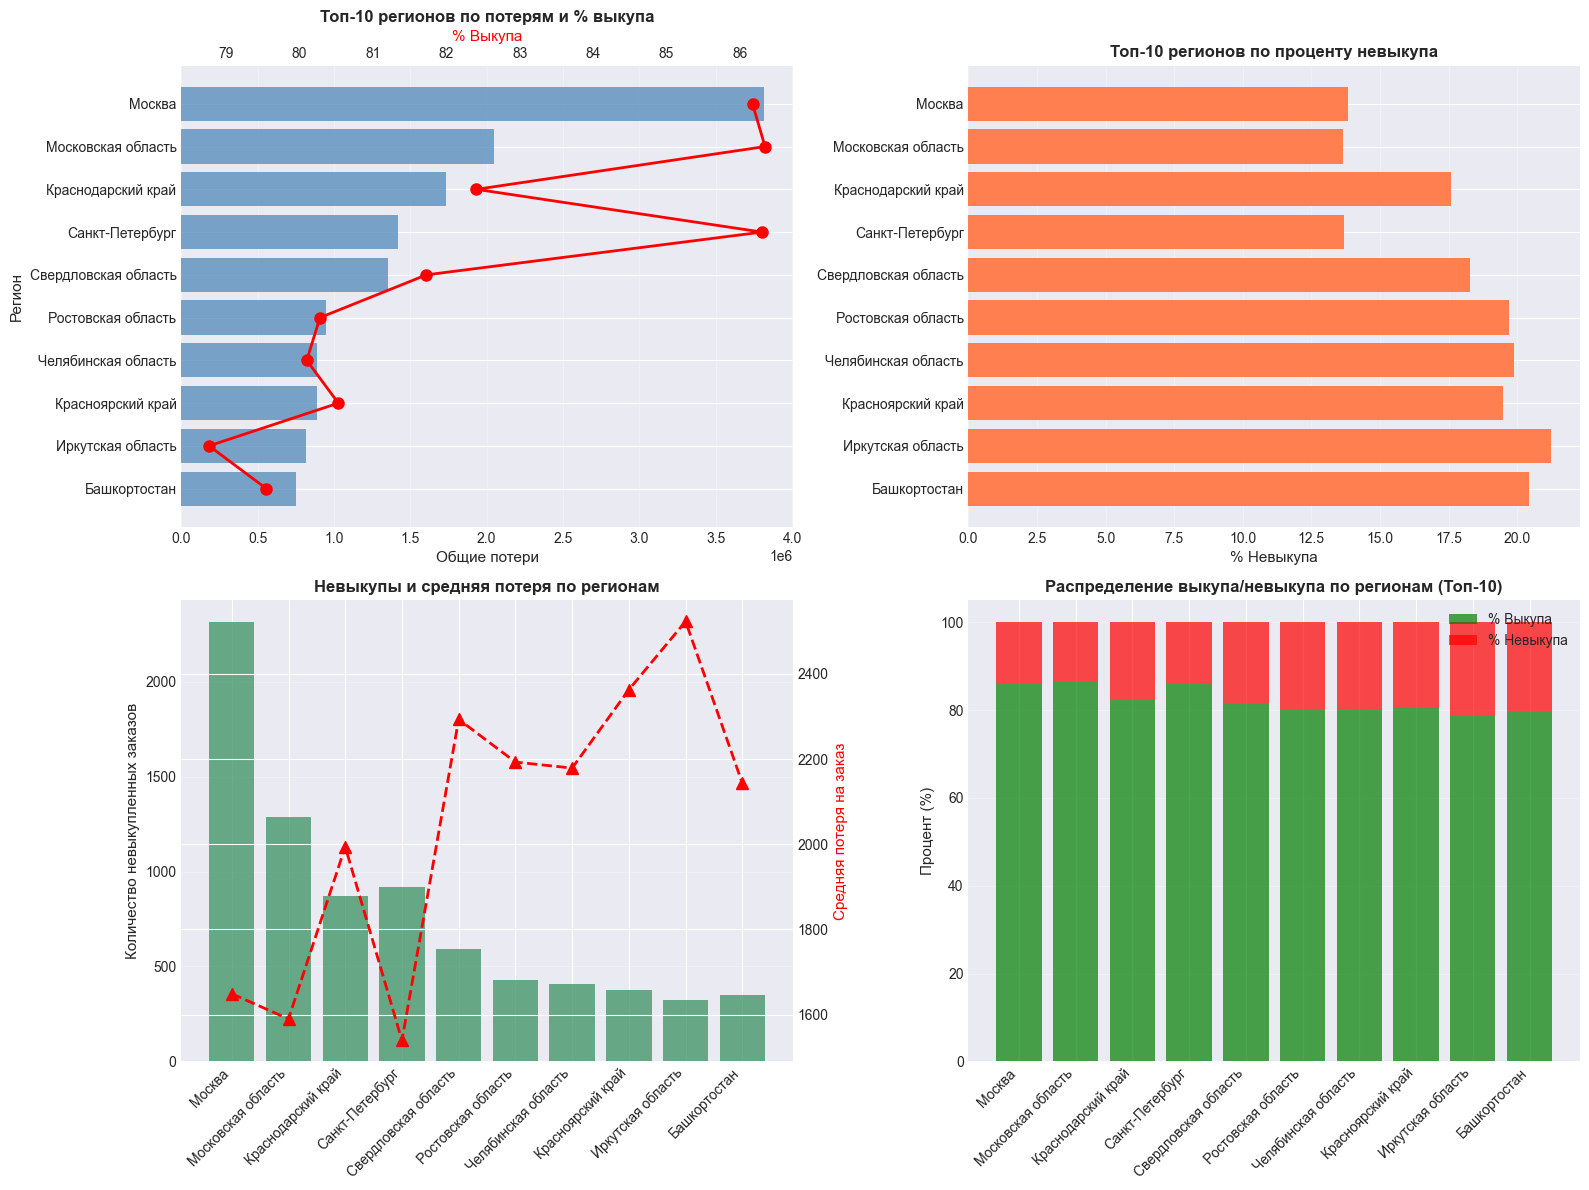

✓ График сохранён в './loss_analysis_results/01_loss_analysis_by_region.png'


In [ ]:
# Созданаем визуализации для потерь по регионам
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# График 1: Топ-10 регионов по общим потерям и % выкупа
top_regions = loss_by_region.head(10).copy()
ax1 = axes[0, 0]
ax1_twin = ax1.twiny()
bars1 = ax1.barh(range(len(top_regions)), top_regions['Total Loss'], color='steelblue', alpha=0.7, label='Потери')
line1 = ax1_twin.plot(top_regions['Buyout Rate %'], range(len(top_regions)), 'ro-', linewidth=2, markersize=8, label='% Выкупа')
ax1.set_yticks(range(len(top_regions)))
ax1.set_yticklabels(top_regions.index)
ax1.set_xlabel('Общие потери', fontsize=11)
ax1.set_ylabel('Регион', fontsize=11)
ax1_twin.set_xlabel('% Выкупа', fontsize=11, color='red')
ax1.set_title('Топ-10 регионов по потерям и % выкупа', fontweight='bold')
ax1.invert_yaxis()
ax1.grid(axis='x', alpha=0.3)
ax1_twin.grid(False)

# График 2: % невыкупа (инвертирование выкупа)
ax2 = axes[0, 1]
top_regions['Non-buyout %'] = 100 - top_regions['Buyout Rate %']
ax2.barh(range(len(top_regions)), top_regions['Non-buyout %'], color='coral')
ax2.set_yticks(range(len(top_regions)))
ax2.set_yticklabels(top_regions.index)
ax2.set_xlabel('% Невыкупа', fontsize=11)
ax2.set_title('Топ-10 регионов по проценту невыкупа', fontweight='bold')
ax2.invert_yaxis()
ax2.grid(axis='x', alpha=0.3)

# График 3: Количество невыкупов и средняя потеря
ax3 = axes[1, 0]
ax3_twin = ax3.twinx()
bars3 = ax3.bar(range(len(top_regions)), top_regions['Non-buyout Orders'], color='seagreen', alpha=0.7, label='Кол-во невыкупов')
line3 = ax3_twin.plot(range(len(top_regions)), top_regions['Avg Loss per Order'], 'r^--', linewidth=2, markersize=8, label='Средняя потеря')
ax3.set_xticks(range(len(top_regions)))
ax3.set_xticklabels(top_regions.index, rotation=45, ha='right')
ax3.set_ylabel('Количество невыкупленных заказов', fontsize=11)
ax3_twin.set_ylabel('Средняя потеря на заказ', fontsize=11, color='red')
ax3.set_title('Невыкупы и средняя потеря по регионам', fontweight='bold')
ax3.grid(axis='y', alpha=0.3)

# График 4: Стопроцентное распределение выкупа/невыкупа
ax4 = axes[1, 1]
x = range(len(top_regions))
ax4.bar(x, top_regions['Buyout Rate %'], label='% Выкупа', color='green', alpha=0.7)
ax4.bar(x, top_regions['Non-buyout %'], bottom=top_regions['Buyout Rate %'], label='% Невыкупа', color='red', alpha=0.7)
ax4.set_xticks(x)
ax4.set_xticklabels(top_regions.index, rotation=45, ha='right')
ax4.set_ylabel('Процент (%)', fontsize=11)
ax4.set_title('Распределение выкупа/невыкупа по регионам (Топ-10)', fontweight='bold')
ax4.legend(fontsize=10)
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{results_folder}/01_loss_analysis_by_region.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ График сохранён в '{results_folder}/01_loss_analysis_by_region.png'")

## 10. Визуализация: Потери по ценовым группам и группам доставки

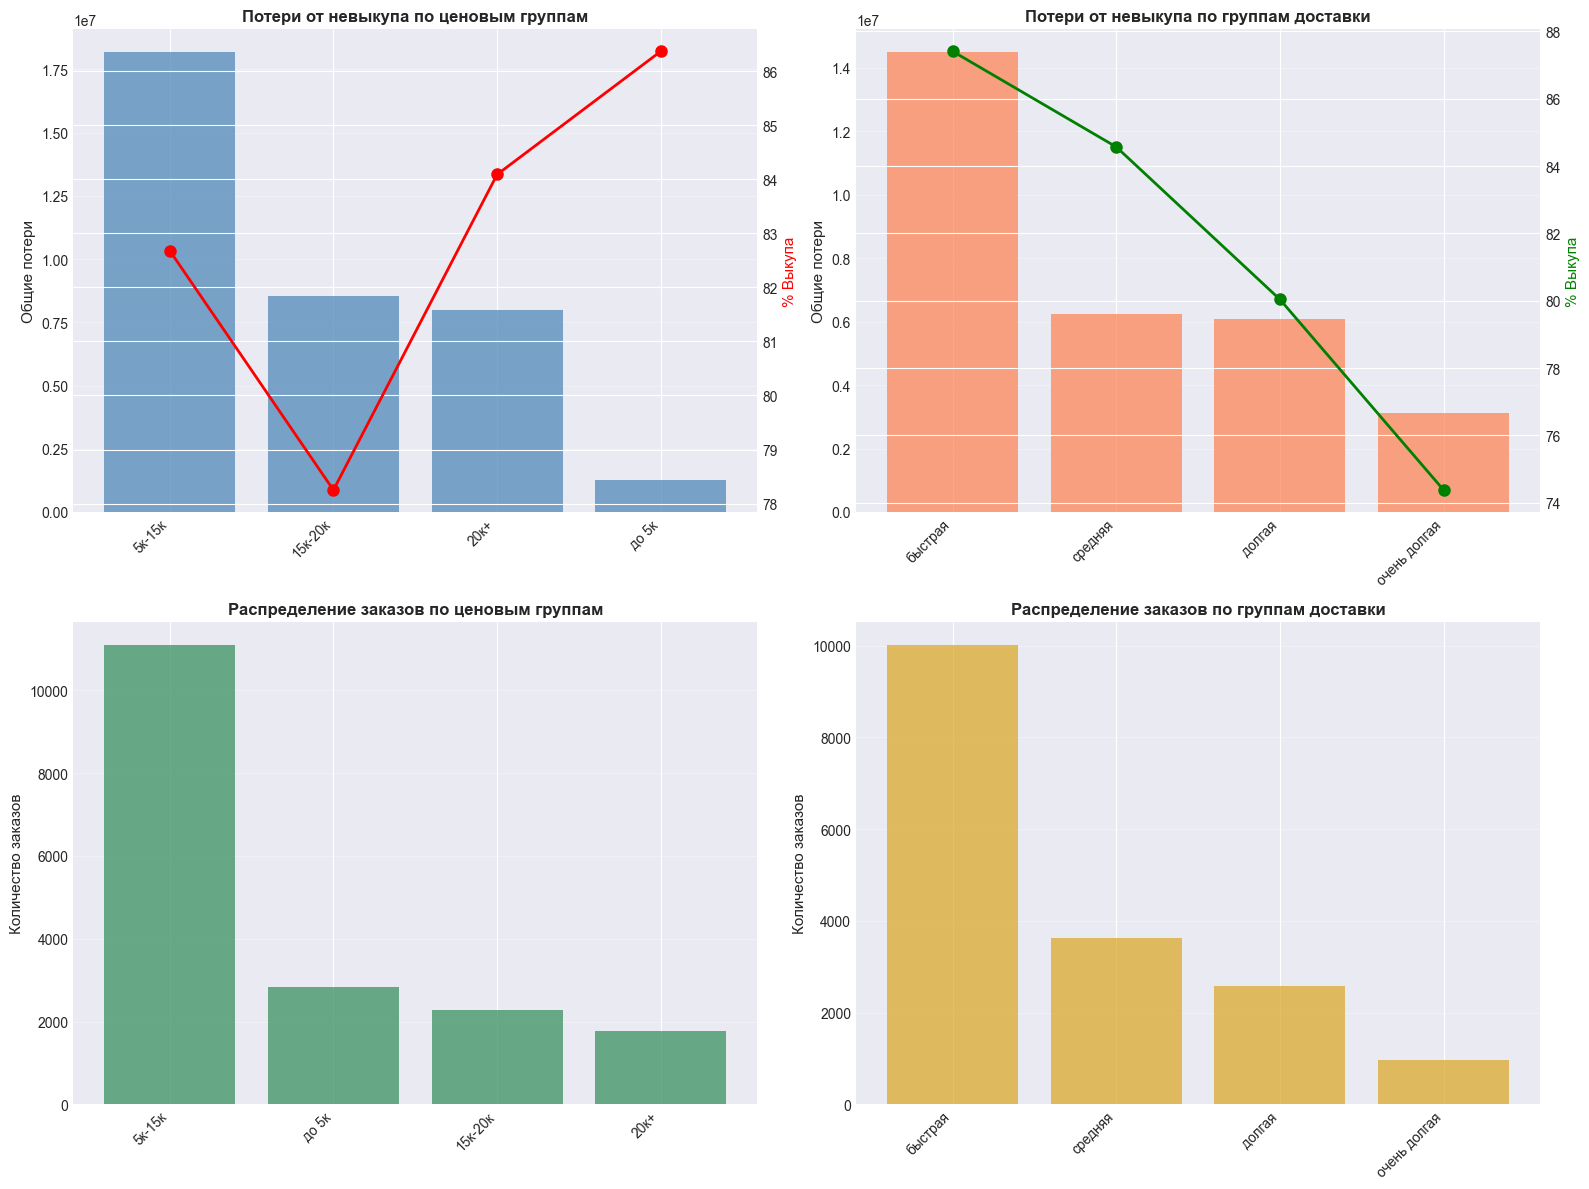

✓ График сохранён в './loss_analysis_results/02_loss_analysis_by_price_delivery.png'


In [ ]:
# Визуализация для ценовых групп и групп доставки с % выкупа
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# График 1: Потери по ценовым группам + % выкупа
loss_by_price_group_sorted = loss_by_price_group.sort_values('Total Loss', ascending=False)
ax1 = axes[0, 0]
ax1_twin = ax1.twinx()
bars1 = ax1.bar(range(len(loss_by_price_group_sorted)), loss_by_price_group_sorted['Total Loss'], color='steelblue', alpha=0.7)
line1 = ax1_twin.plot(range(len(loss_by_price_group_sorted)), loss_by_price_group_sorted['Buyout Rate %'], 'ro-', linewidth=2, markersize=8)
ax1.set_xticks(range(len(loss_by_price_group_sorted)))
ax1.set_xticklabels(loss_by_price_group_sorted.index, rotation=45, ha='right')
ax1.set_ylabel('Общие потери', fontsize=11)
ax1_twin.set_ylabel('% Выкупа', fontsize=11, color='red')
ax1.set_title('Потери от невыкупа по ценовым группам', fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# График 2: Потери по группам доставки + % выкупа
loss_by_delivery_group_sorted = loss_by_delivery_group.sort_values('Total Loss', ascending=False)
ax2 = axes[0, 1]
ax2_twin = ax2.twinx()
bars2 = ax2.bar(range(len(loss_by_delivery_group_sorted)), loss_by_delivery_group_sorted['Total Loss'], color='coral', alpha=0.7)
line2 = ax2_twin.plot(range(len(loss_by_delivery_group_sorted)), loss_by_delivery_group_sorted['Buyout Rate %'], 'go-', linewidth=2, markersize=8)
ax2.set_xticks(range(len(loss_by_delivery_group_sorted)))
ax2.set_xticklabels(loss_by_delivery_group_sorted.index, rotation=45, ha='right')
ax2.set_ylabel('Общие потери', fontsize=11)
ax2_twin.set_ylabel('% Выкупа', fontsize=11, color='green')
ax2.set_title('Потери от невыкупа по группам доставки', fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# График 3: Кол-во заказов по ценовым группам
ax3 = axes[1, 0]
price_order_counts = df.groupby('price_group').size().sort_values(ascending=False)
ax3.bar(range(len(price_order_counts)), price_order_counts, color='seagreen', alpha=0.7)
ax3.set_xticks(range(len(price_order_counts)))
ax3.set_xticklabels(price_order_counts.index, rotation=45, ha='right')
ax3.set_ylabel('Количество заказов', fontsize=11)
ax3.set_title('Распределение заказов по ценовым группам', fontweight='bold')
ax3.grid(axis='y', alpha=0.3)

# График 4: Кол-во заказов по группам доставки
ax4 = axes[1, 1]
delivery_order_counts = df.groupby('delivery_group').size().sort_values(ascending=False)
ax4.bar(range(len(delivery_order_counts)), delivery_order_counts, color='goldenrod', alpha=0.7)
ax4.set_xticks(range(len(delivery_order_counts)))
ax4.set_xticklabels(delivery_order_counts.index, rotation=45, ha='right')
ax4.set_ylabel('Количество заказов', fontsize=11)
ax4.set_title('Распределение заказов по группам доставки', fontweight='bold')
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{results_folder}/02_loss_analysis_by_price_delivery.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ График сохранён в '{results_folder}/02_loss_analysis_by_price_delivery.png'")

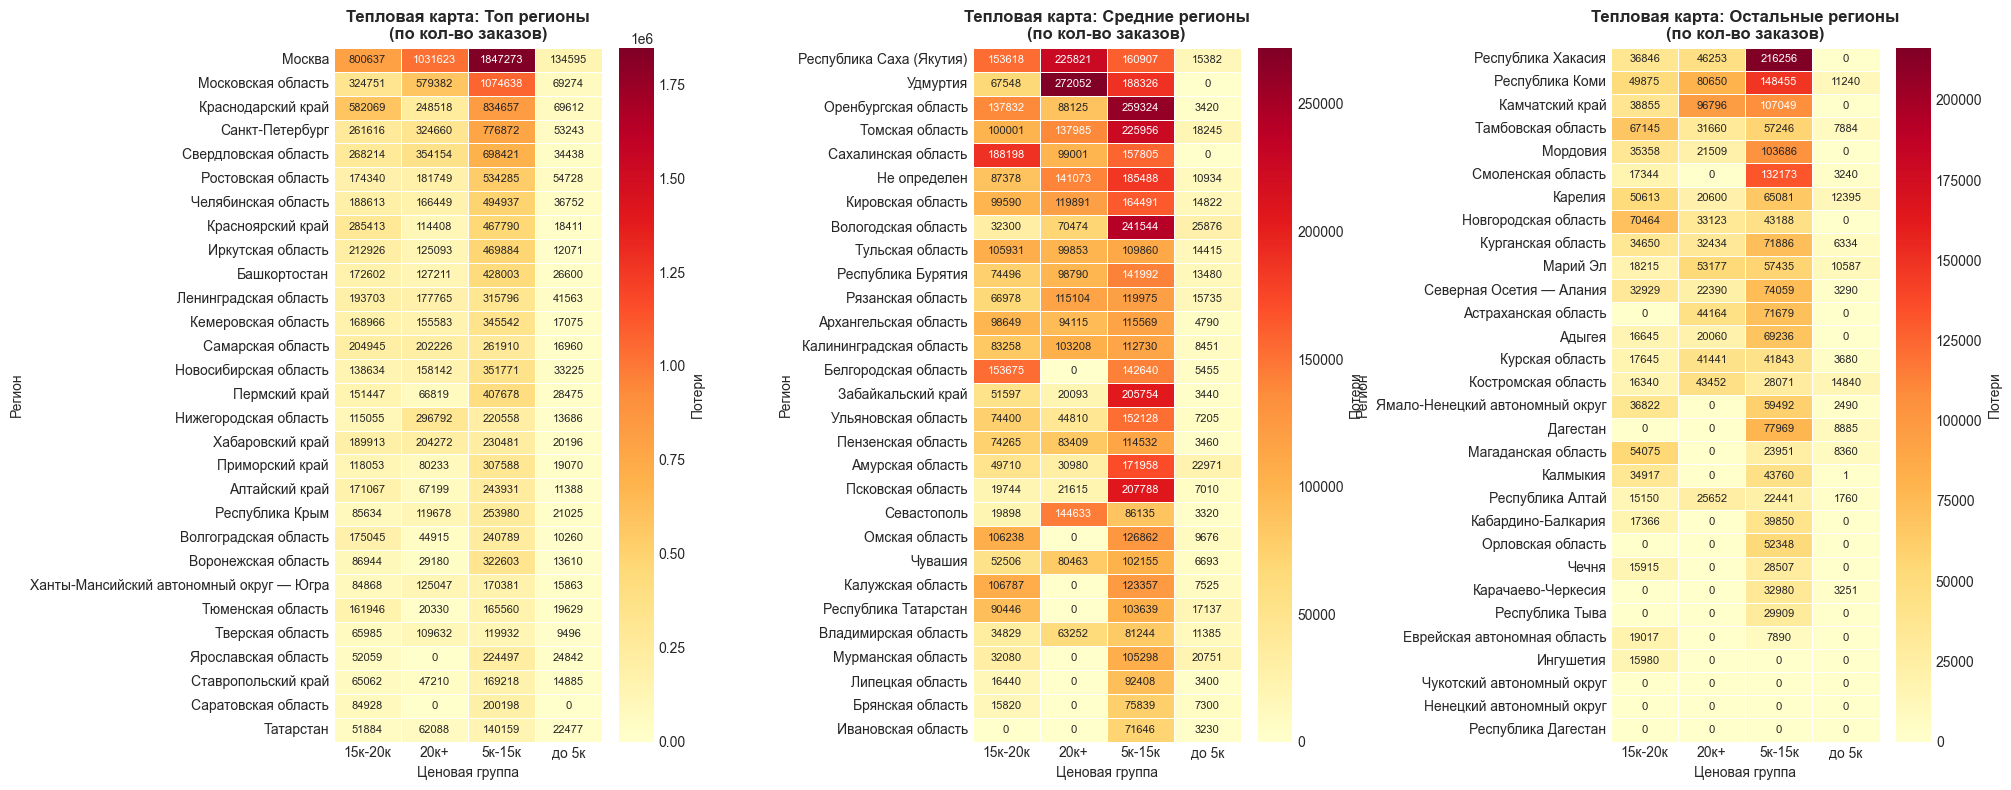

✓ Тепловые карты сохранены в './loss_analysis_results/03_heatmap_region_price.png'
  - Топ регионов: 29 регионов
  - Средние регионы: 29 регионов
  - Остальные регионы: 30 регионов


In [ ]:
# Отдельный график: Тепловые карты разделены на 3 части (по количеству заказов)
# Разделяем регионы на 3 трети по количеству заказов

# Считаем количество заказов по регионам
region_order_counts = df.groupby('lead_region').size().sort_values(ascending=False)

# Разделяем регионы на 3 части
third = len(region_order_counts) // 3
top_third_regions = region_order_counts.head(third).index.tolist()
middle_third_regions = region_order_counts.iloc[third:2*third].index.tolist()
bottom_third_regions = region_order_counts.iloc[2*third:].index.tolist()

# Создаем 3 отдельные тепловые карты
fig, axes = plt.subplots(1, 3, figsize=(20, 8))

# Карта 1: ТОП регионов (верхняя треть по кол-во заказов)
pivot_top = pivot_region_price.loc[top_third_regions]
row_sums_top = pivot_top.sum(axis=1)
pivot_top = pivot_top.reindex(row_sums_top.sort_values(ascending=False).index)
sns.heatmap(pivot_top, annot=True, fmt='.0f', cmap='YlOrRd', ax=axes[0], 
            cbar_kws={'label': 'Потери'}, linewidths=0.5, annot_kws={'size': 8})
axes[0].set_title(f'Тепловая карта: Топ регионы\n(по кол-во заказов)', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Ценовая группа', fontsize=10)
axes[0].set_ylabel('Регион', fontsize=10)

# Карта 2: СРЕДНИЕ регионы (средняя треть по кол-во заказов)
pivot_middle = pivot_region_price.loc[middle_third_regions]
row_sums_middle = pivot_middle.sum(axis=1)
pivot_middle = pivot_middle.reindex(row_sums_middle.sort_values(ascending=False).index)
sns.heatmap(pivot_middle, annot=True, fmt='.0f', cmap='YlOrRd', ax=axes[1], 
            cbar_kws={'label': 'Потери'}, linewidths=0.5, annot_kws={'size': 8})
axes[1].set_title(f'Тепловая карта: Средние регионы\n(по кол-во заказов)', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Ценовая группа', fontsize=10)
axes[1].set_ylabel('Регион', fontsize=10)

# Карта 3: НИЖНИе регионы (нижняя треть по кол-во заказов)
pivot_bottom = pivot_region_price.loc[bottom_third_regions]
row_sums_bottom = pivot_bottom.sum(axis=1)
pivot_bottom = pivot_bottom.reindex(row_sums_bottom.sort_values(ascending=False).index)
sns.heatmap(pivot_bottom, annot=True, fmt='.0f', cmap='YlOrRd', ax=axes[2], 
            cbar_kws={'label': 'Потери'}, linewidths=0.5, annot_kws={'size': 8})
axes[2].set_title(f'Тепловая карта: Остальные регионы\n(по кол-во заказов)', fontweight='bold', fontsize=12)
axes[2].set_xlabel('Ценовая группа', fontsize=10)
axes[2].set_ylabel('Регион', fontsize=10)

plt.tight_layout()
plt.savefig(f'{results_folder}/03_heatmap_region_price.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Тепловые карты сохранены в '{results_folder}/03_heatmap_region_price.png'")
print(f"  - Топ регионов: {len(top_third_regions)} регионов")
print(f"  - Средние регионы: {len(middle_third_regions)} регионов")
print(f"  - Остальные регионы: {len(bottom_third_regions)} регионов")

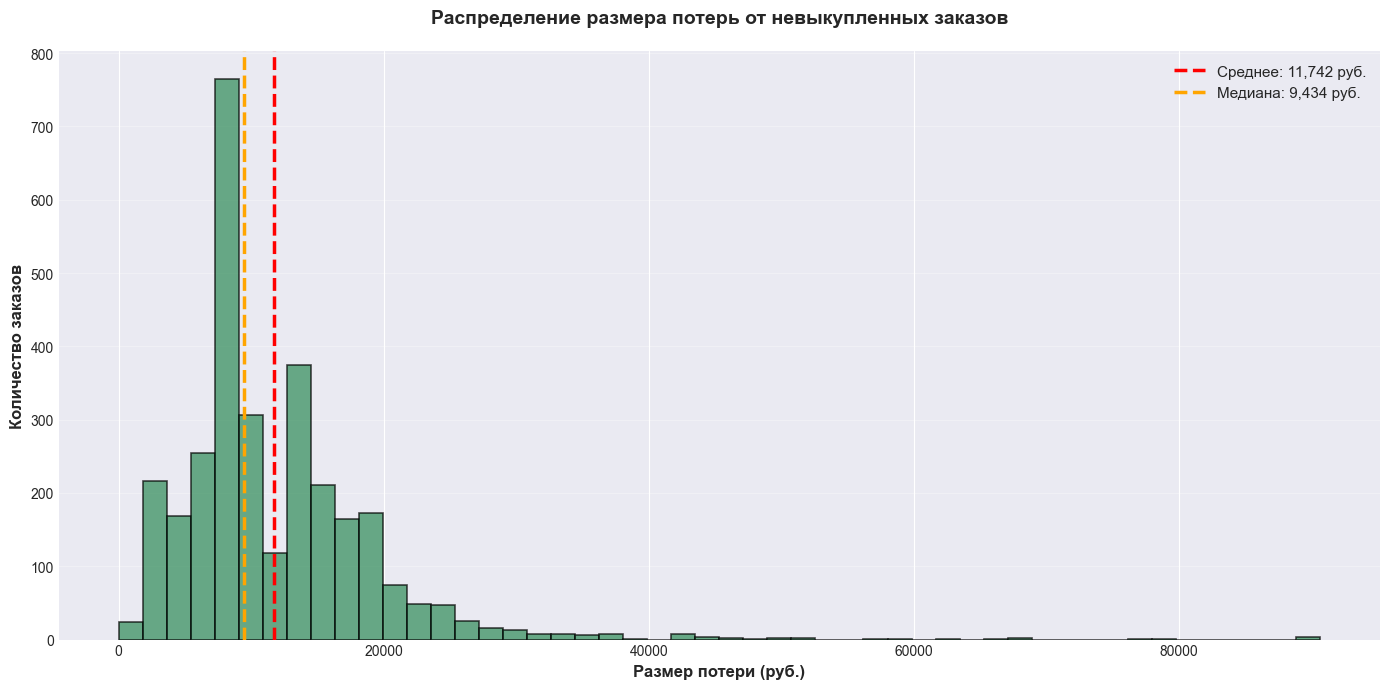

✓ Гистограмма сохранена в './loss_analysis_results/04_loss_distribution_histogram.png'


In [ ]:
# Гистограмма: Распределение размера потерь для невыкупленных заказов
fig, ax = plt.subplots(figsize=(14, 7))

loss_data = df[df['loss'] > 0]['loss'].values
ax.hist(loss_data, bins=50, color='seagreen', alpha=0.7, edgecolor='black', linewidth=1.2)
ax.set_xlabel('Размер потери (руб.)', fontsize=12, fontweight='bold')
ax.set_ylabel('Количество заказов', fontsize=12, fontweight='bold')
ax.set_title('Распределение размера потерь от невыкупленных заказов', fontsize=14, fontweight='bold', pad=20)

# Добавим линию среднего значения
mean_loss = np.mean(loss_data)
median_loss = np.median(loss_data)
ax.axvline(mean_loss, color='red', linestyle='--', linewidth=2.5, label=f'Среднее: {mean_loss:,.0f} руб.')
ax.axvline(median_loss, color='orange', linestyle='--', linewidth=2.5, label=f'Медиана: {median_loss:,.0f} руб.')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{results_folder}/04_loss_distribution_histogram.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Гистограмма сохранена в '{results_folder}/04_loss_distribution_histogram.png'")

## 10в. Визуализация: Распределение размера потерь

## 10б. Визуализация: Тепловая карта (Регион × Ценовая группа)

## 11. Визуализация: Круговые диаграммы распределения потерь

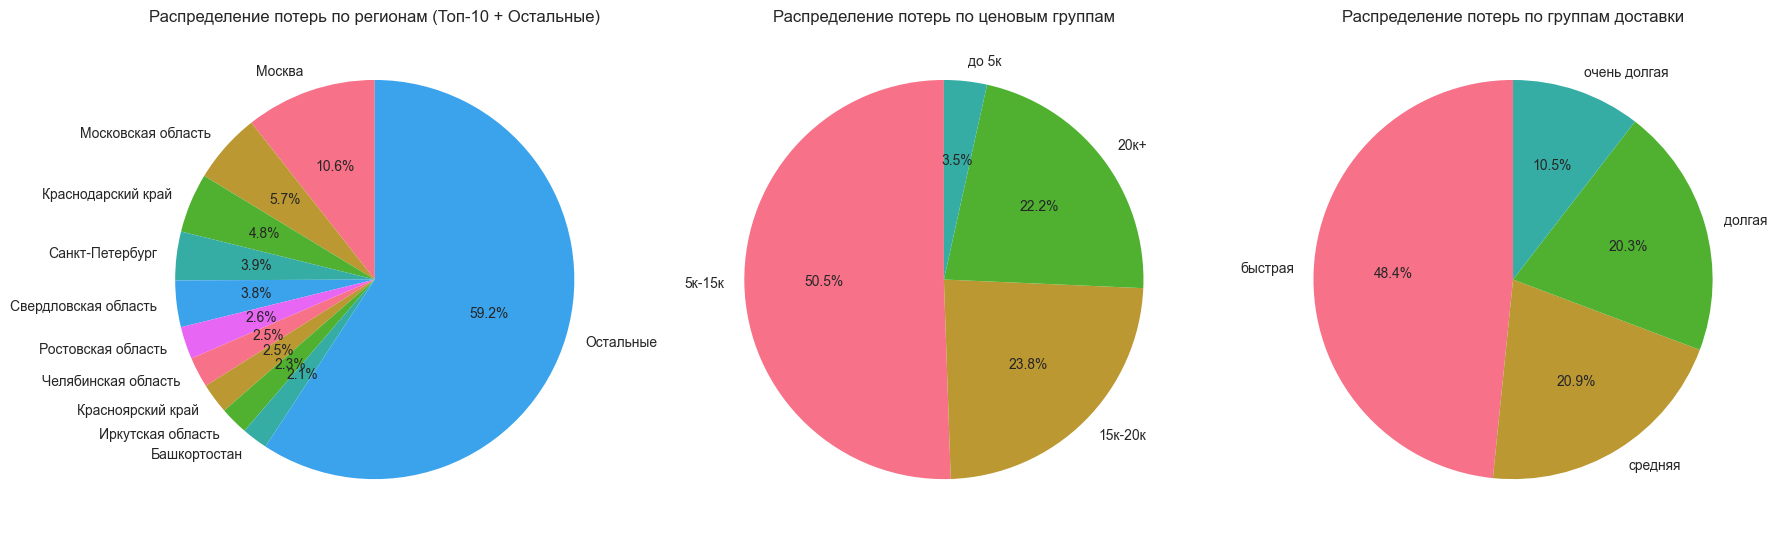

✓ Круговые диаграммы сохранены в './loss_analysis_results/05_loss_distribution_pie_charts.png'


In [ ]:
# Круговые диаграммы
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Диаграмма 1: Распределение потерь по регионам (Топ-10)
ax1 = axes[0]
top_regions_pie = loss_by_region['Total Loss'].head(10)
other_loss = loss_by_region['Total Loss'].iloc[10:].sum()
if other_loss > 0:
    top_regions_pie = pd.concat([top_regions_pie, pd.Series({'Остальные': other_loss})])

ax1.pie(top_regions_pie, labels=top_regions_pie.index, autopct='%1.1f%%', startangle=90)
ax1.set_title('Распределение потерь по регионам (Топ-10 + Остальные)')

# Диаграмма 2: Распределение потерь по ценовым группам
ax2 = axes[1]
ax2.pie(loss_by_price_group['Total Loss'], labels=loss_by_price_group.index, autopct='%1.1f%%', startangle=90)
ax2.set_title('Распределение потерь по ценовым группам')

# Диаграмма 3: Распределение потерь по группам доставки
ax3 = axes[2]
ax3.pie(loss_by_delivery_group['Total Loss'], labels=loss_by_delivery_group.index, autopct='%1.1f%%', startangle=90)
ax3.set_title('Распределение потерь по группам доставки')

plt.tight_layout()
plt.savefig(f'{results_folder}/05_loss_distribution_pie_charts.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Круговые диаграммы сохранены в '{results_folder}/05_loss_distribution_pie_charts.png'")

## 11б. Визуализация: Графики по новым категориям

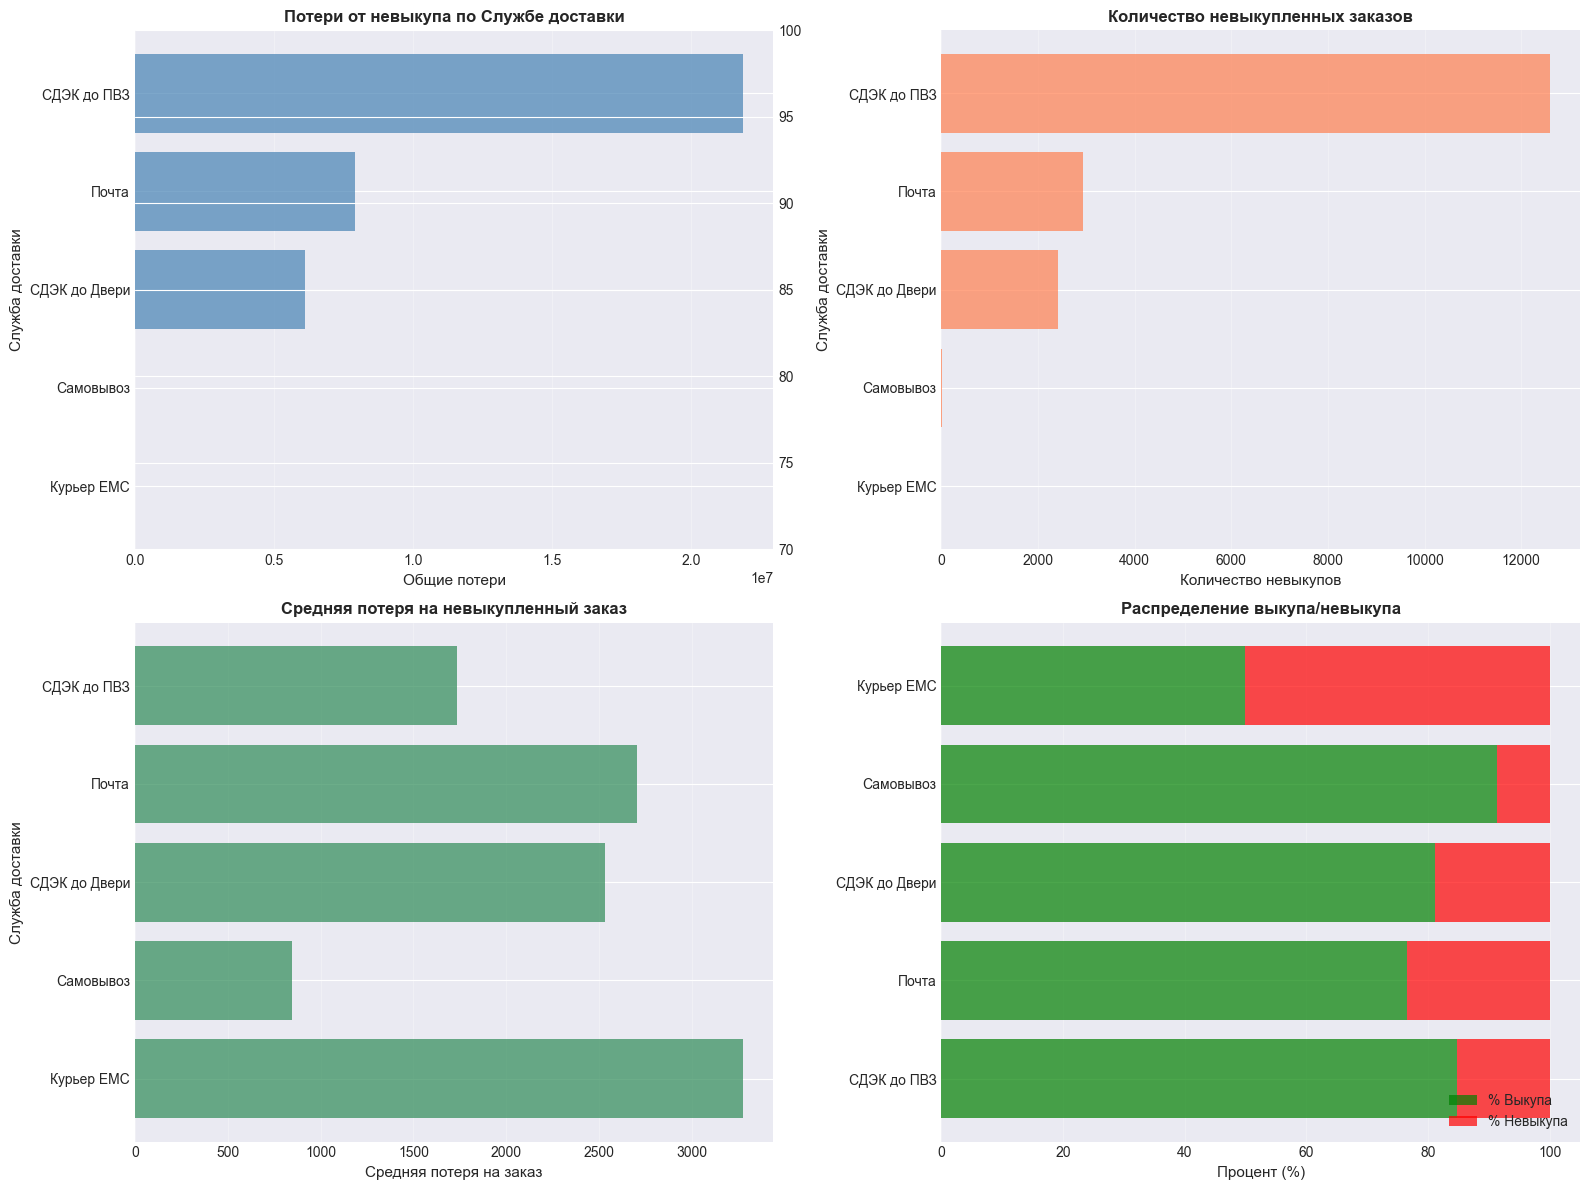

✓ График сохранён в './loss_analysis_results/06_loss_analysis_by_delivery_service.png'


In [ ]:
# Графики для Службы доставки
try:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # График 1: Потери по Службе доставки + % выкупа
    loss_by_delivery_service_sorted = loss_by_delivery_service.sort_values('Total Loss', ascending=False)
    ax1 = axes[0, 0]
    ax1_twin = ax1.twinx()
    bars1 = ax1.barh(range(len(loss_by_delivery_service_sorted)), loss_by_delivery_service_sorted['Total Loss'], 
                     color='steelblue', alpha=0.7)
    line1 = ax1_twin.plot(loss_by_delivery_service_sorted['Buyout Rate %'], range(len(loss_by_delivery_service_sorted)), 
                         'ro-', linewidth=2, markersize=8)
    ax1.set_yticks(range(len(loss_by_delivery_service_sorted)))
    ax1.set_yticklabels(loss_by_delivery_service_sorted.index)
    ax1.set_xlabel('Общие потери', fontsize=11)
    ax1.set_ylabel('Служба доставки', fontsize=11)
    ax1_twin.set_xlabel('% Выкупа', fontsize=11, color='red')
    ax1_twin.set_ylim(70, 100)
    ax1.set_title('Потери от невыкупа по Службе доставки', fontweight='bold')
    ax1.invert_yaxis()
    ax1.grid(axis='x', alpha=0.3)
    
    # График 2: Количество невыкупов по Службе доставки
    ax2 = axes[0, 1]
    ax2.barh(range(len(loss_by_delivery_service_sorted)), loss_by_delivery_service_sorted['Non-buyout Orders'], 
            color='coral', alpha=0.7)
    ax2.set_yticks(range(len(loss_by_delivery_service_sorted)))
    ax2.set_yticklabels(loss_by_delivery_service_sorted.index)
    ax2.set_xlabel('Количество невыкупов', fontsize=11)
    ax2.set_ylabel('Служба доставки', fontsize=11)
    ax2.set_title('Количество невыкупленных заказов', fontweight='bold')
    ax2.invert_yaxis()
    ax2.grid(axis='x', alpha=0.3)
    
    # График 3: Средняя потеря
    ax3 = axes[1, 0]
    ax3.barh(range(len(loss_by_delivery_service_sorted)), loss_by_delivery_service_sorted['Avg Loss per Order'], 
            color='seagreen', alpha=0.7)
    ax3.set_yticks(range(len(loss_by_delivery_service_sorted)))
    ax3.set_yticklabels(loss_by_delivery_service_sorted.index)
    ax3.set_xlabel('Средняя потеря на заказ', fontsize=11)
    ax3.set_ylabel('Служба доставки', fontsize=11)
    ax3.set_title('Средняя потеря на невыкупленный заказ', fontweight='bold')
    ax3.invert_yaxis()
    ax3.grid(axis='x', alpha=0.3)
    
    # График 4: Распределение выкупа/невыкупа
    ax4 = axes[1, 1]
    non_buyout_pct = 100 - loss_by_delivery_service_sorted['Buyout Rate %']
    x = range(len(loss_by_delivery_service_sorted))
    ax4.barh(x, loss_by_delivery_service_sorted['Buyout Rate %'], label='% Выкупа', color='green', alpha=0.7)
    ax4.barh(x, non_buyout_pct, left=loss_by_delivery_service_sorted['Buyout Rate %'], 
            label='% Невыкупа', color='red', alpha=0.7)
    ax4.set_yticks(range(len(loss_by_delivery_service_sorted)))
    ax4.set_yticklabels(loss_by_delivery_service_sorted.index)
    ax4.set_xlabel('Процент (%)', fontsize=11)
    ax4.set_title('Распределение выкупа/невыкупа', fontweight='bold')
    ax4.legend(fontsize=10, loc='lower right')
    ax4.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'{results_folder}/06_loss_analysis_by_delivery_service.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✓ График сохранён в '{results_folder}/06_loss_analysis_by_delivery_service.png'")
except Exception as e:
    print(f"⚠️ Ошибка при создании графиков для Службы доставки: {e}")

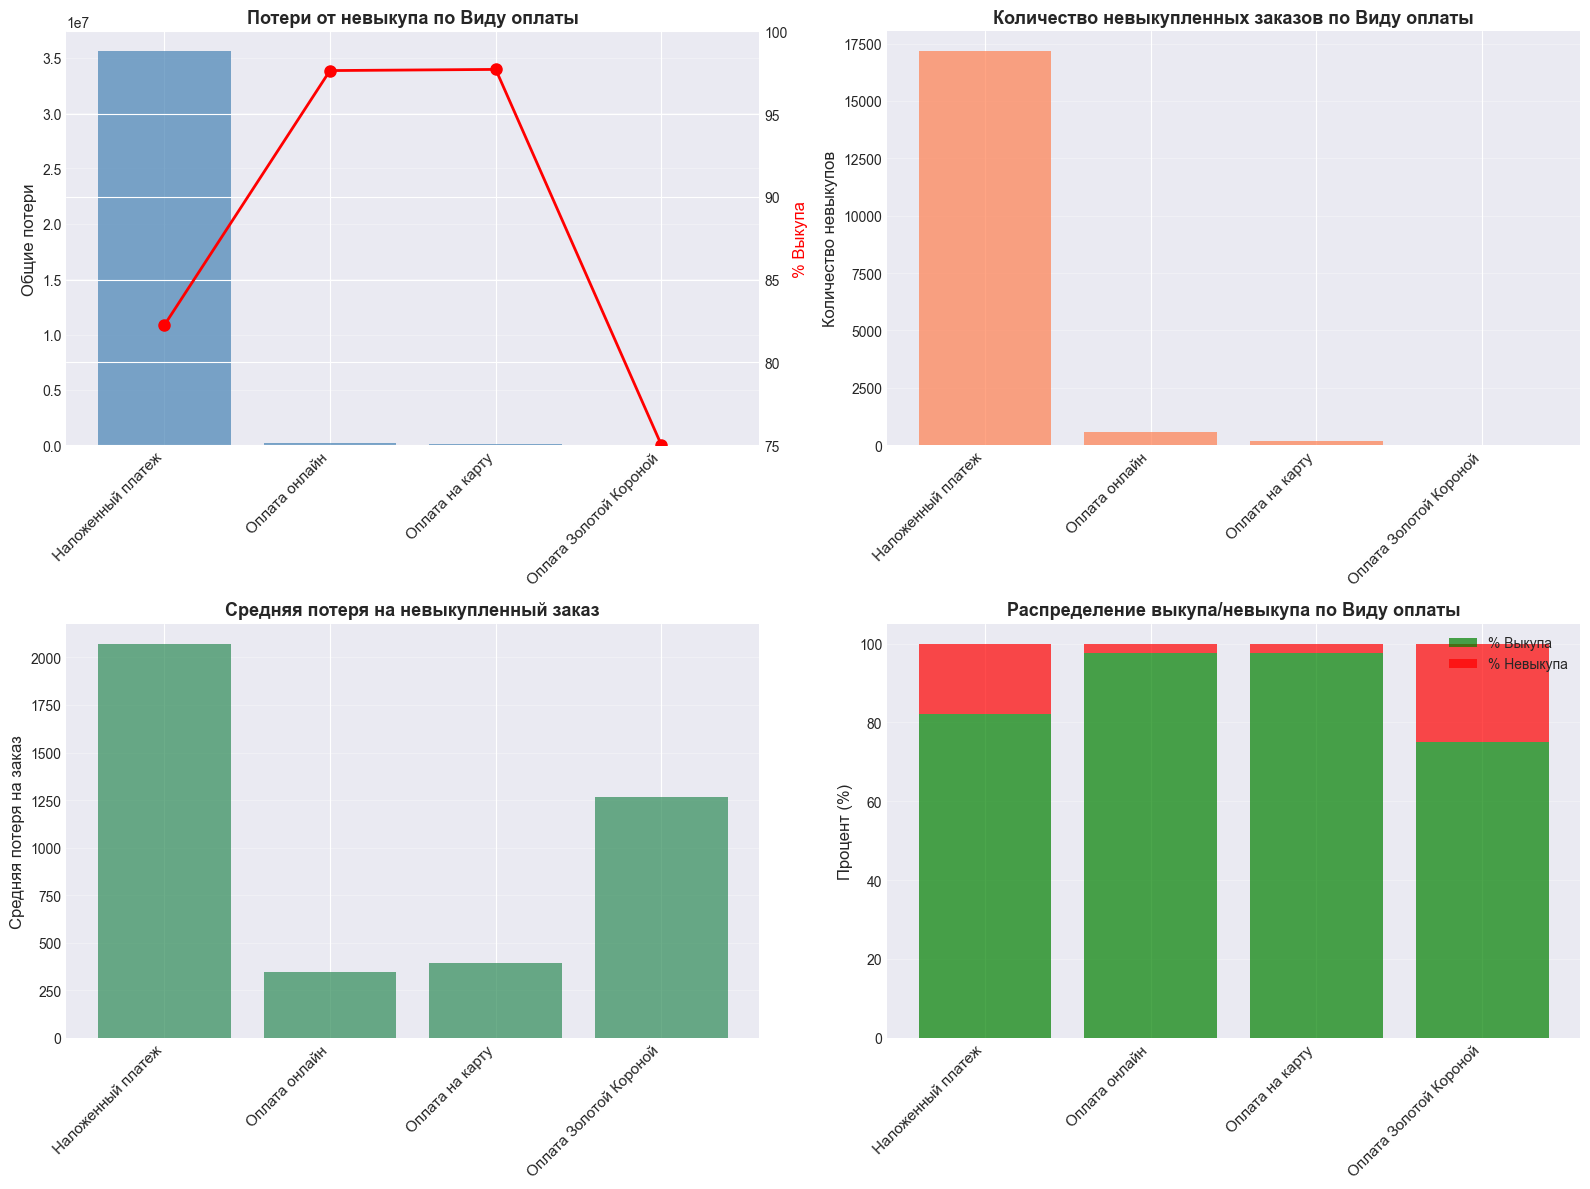

✓ График сохранён в './loss_analysis_results/07_loss_analysis_by_payment_type.png'


In [ ]:
# Графики для Вида оплаты
try:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # График 1: Потери по Виду оплаты + % выкупа
    loss_by_payment_type_sorted = loss_by_payment_type.sort_values('Total Loss', ascending=False)
    ax1 = axes[0, 0]
    ax1_twin = ax1.twinx()
    bars1 = ax1.bar(range(len(loss_by_payment_type_sorted)), loss_by_payment_type_sorted['Total Loss'], 
                   color='steelblue', alpha=0.7)
    line1 = ax1_twin.plot(range(len(loss_by_payment_type_sorted)), loss_by_payment_type_sorted['Buyout Rate %'], 
                         'ro-', linewidth=2, markersize=8)
    ax1_twin.set_ylim(75, 100)
    ax1.set_xticks(range(len(loss_by_payment_type_sorted)))
    ax1.set_xticklabels(loss_by_payment_type_sorted.index, rotation=45, ha='right', fontsize=11)
    ax1.set_ylabel('Общие потери', fontsize=12)
    ax1_twin.set_ylabel('% Выкупа', fontsize=12, color='red')
    ax1.set_title('Потери от невыкупа по Виду оплаты', fontweight='bold', fontsize=13)
    ax1.grid(axis='y', alpha=0.3)
    
    # График 2: Количество невыкупов
    ax2 = axes[0, 1]
    ax2.bar(range(len(loss_by_payment_type_sorted)), loss_by_payment_type_sorted['Non-buyout Orders'], 
           color='coral', alpha=0.7)
    ax2.set_xticks(range(len(loss_by_payment_type_sorted)))
    ax2.set_xticklabels(loss_by_payment_type_sorted.index, rotation=45, ha='right', fontsize=11)
    ax2.set_ylabel('Количество невыкупов', fontsize=12)
    ax2.set_title('Количество невыкупленных заказов по Виду оплаты', fontweight='bold', fontsize=13)
    ax2.grid(axis='y', alpha=0.3)
    
    # График 3: Средняя потеря
    ax3 = axes[1, 0]
    ax3.bar(range(len(loss_by_payment_type_sorted)), loss_by_payment_type_sorted['Avg Loss per Order'], 
           color='seagreen', alpha=0.7)
    ax3.set_xticks(range(len(loss_by_payment_type_sorted)))
    ax3.set_xticklabels(loss_by_payment_type_sorted.index, rotation=45, ha='right', fontsize=11)
    ax3.set_ylabel('Средняя потеря на заказ', fontsize=12)
    ax3.set_title('Средняя потеря на невыкупленный заказ', fontweight='bold', fontsize=13)
    ax3.grid(axis='y', alpha=0.3)
    
    # График 4: Распределение выкупа/невыкупа
    ax4 = axes[1, 1]
    non_buyout_pct = 100 - loss_by_payment_type_sorted['Buyout Rate %']
    x = range(len(loss_by_payment_type_sorted))
    ax4.bar(x, loss_by_payment_type_sorted['Buyout Rate %'], label='% Выкупа', color='green', alpha=0.7)
    ax4.bar(x, non_buyout_pct, bottom=loss_by_payment_type_sorted['Buyout Rate %'], 
           label='% Невыкупа', color='red', alpha=0.7)
    ax4.set_xticks(range(len(loss_by_payment_type_sorted)))
    ax4.set_xticklabels(loss_by_payment_type_sorted.index, rotation=45, ha='right', fontsize=11)
    ax4.set_ylabel('Процент (%)', fontsize=12)
    ax4.set_title('Распределение выкупа/невыкупа по Виду оплаты', fontweight='bold', fontsize=13)
    ax4.legend(fontsize=10)
    ax4.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'{results_folder}/07_loss_analysis_by_payment_type.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✓ График сохранён в '{results_folder}/07_loss_analysis_by_payment_type.png'")
except Exception as e:
    print(f"⚠️ Ошибка при создании графиков для Вида оплаты: {e}")

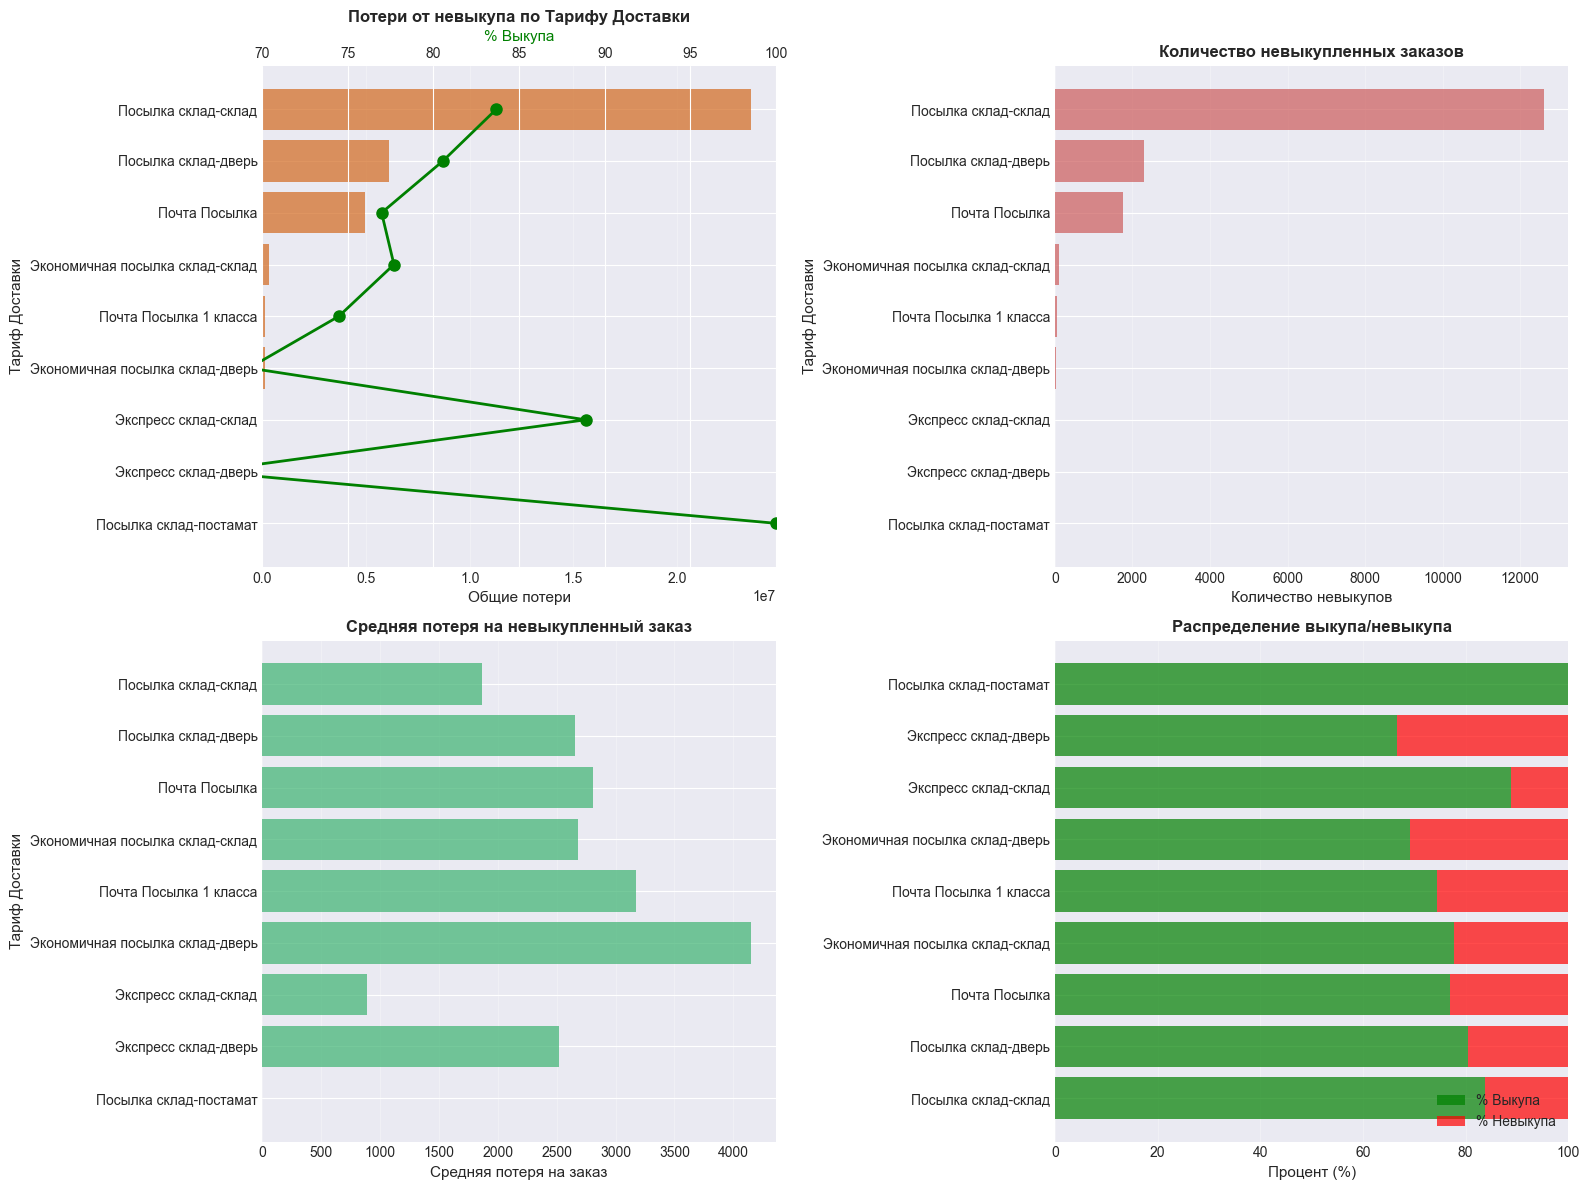

✓ График сохранён в './loss_analysis_results/09_loss_analysis_by_delivery_tariff.png'


In [ ]:
# Графики для Тарифа Доставки
try:
    loss_by_delivery_tariff_sorted = loss_by_delivery_tariff.sort_values('Total Loss', ascending=False)
    
    if len(loss_by_delivery_tariff_sorted) > 0:
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))
        
        # График 1: Потери по Тарифу Доставки + % выкупа
        ax1 = axes[0, 0]
        ax1_twin = ax1.twiny()
        bars1 = ax1.barh(range(len(loss_by_delivery_tariff_sorted)), loss_by_delivery_tariff_sorted['Total Loss'], 
                        color='chocolate', alpha=0.7)
        line1 = ax1_twin.plot(loss_by_delivery_tariff_sorted['Buyout Rate %'].values, range(len(loss_by_delivery_tariff_sorted)), 
                             'go-', linewidth=2, markersize=8)
        ax1_twin.set_xlim(70, 100)
        ax1.set_yticks(range(len(loss_by_delivery_tariff_sorted)))
        ax1.set_yticklabels(loss_by_delivery_tariff_sorted.index)
        ax1.set_xlabel('Общие потери', fontsize=11)
        ax1.set_ylabel('Тариф Доставки', fontsize=11)
        ax1_twin.set_xlabel('% Выкупа', fontsize=11, color='green')
        ax1.set_title('Потери от невыкупа по Тарифу Доставки', fontweight='bold')
        ax1.invert_yaxis()
        ax1.grid(axis='x', alpha=0.3)
        
        # График 2: Количество невыкупов
        ax2 = axes[0, 1]
        ax2.barh(range(len(loss_by_delivery_tariff_sorted)), loss_by_delivery_tariff_sorted['Non-buyout Orders'], 
                color='indianred', alpha=0.7)
        ax2.set_yticks(range(len(loss_by_delivery_tariff_sorted)))
        ax2.set_yticklabels(loss_by_delivery_tariff_sorted.index)
        ax2.set_xlabel('Количество невыкупов', fontsize=11)
        ax2.set_ylabel('Тариф Доставки', fontsize=11)
        ax2.set_title('Количество невыкупленных заказов', fontweight='bold')
        ax2.invert_yaxis()
        ax2.grid(axis='x', alpha=0.3)
        
        # График 3: Средняя потеря
        ax3 = axes[1, 0]
        ax3.barh(range(len(loss_by_delivery_tariff_sorted)), loss_by_delivery_tariff_sorted['Avg Loss per Order'], 
                color='mediumseagreen', alpha=0.7)
        ax3.set_yticks(range(len(loss_by_delivery_tariff_sorted)))
        ax3.set_yticklabels(loss_by_delivery_tariff_sorted.index)
        ax3.set_xlabel('Средняя потеря на заказ', fontsize=11)
        ax3.set_ylabel('Тариф Доставки', fontsize=11)
        ax3.set_title('Средняя потеря на невыкупленный заказ', fontweight='bold')
        ax3.invert_yaxis()
        ax3.grid(axis='x', alpha=0.3)
        
        # График 4: Распределение выкупа/невыкупа
        ax4 = axes[1, 1]
        non_buyout_pct = 100 - loss_by_delivery_tariff_sorted['Buyout Rate %']
        x = range(len(loss_by_delivery_tariff_sorted))
        ax4.barh(x, loss_by_delivery_tariff_sorted['Buyout Rate %'], label='% Выкупа', color='green', alpha=0.7)
        ax4.barh(x, non_buyout_pct, left=loss_by_delivery_tariff_sorted['Buyout Rate %'], 
                label='% Невыкупа', color='red', alpha=0.7)
        ax4.set_yticks(range(len(loss_by_delivery_tariff_sorted)))
        ax4.set_yticklabels(loss_by_delivery_tariff_sorted.index)
        ax4.set_xlabel('Процент (%)', fontsize=11)
        ax4.set_title('Распределение выкупа/невыкупа', fontweight='bold')
        ax4.legend(fontsize=10, loc='lower right')
        ax4.grid(axis='x', alpha=0.3)
        
        plt.tight_layout()
        plt.savefig(f'{results_folder}/09_loss_analysis_by_delivery_tariff.png', dpi=300, bbox_inches='tight')
        plt.show()
        print(f"✓ График сохранён в '{results_folder}/09_loss_analysis_by_delivery_tariff.png'")
except Exception as e:
    print(f"⚠️ Ошибка при создании графиков для Тарифа Доставки: {e}")

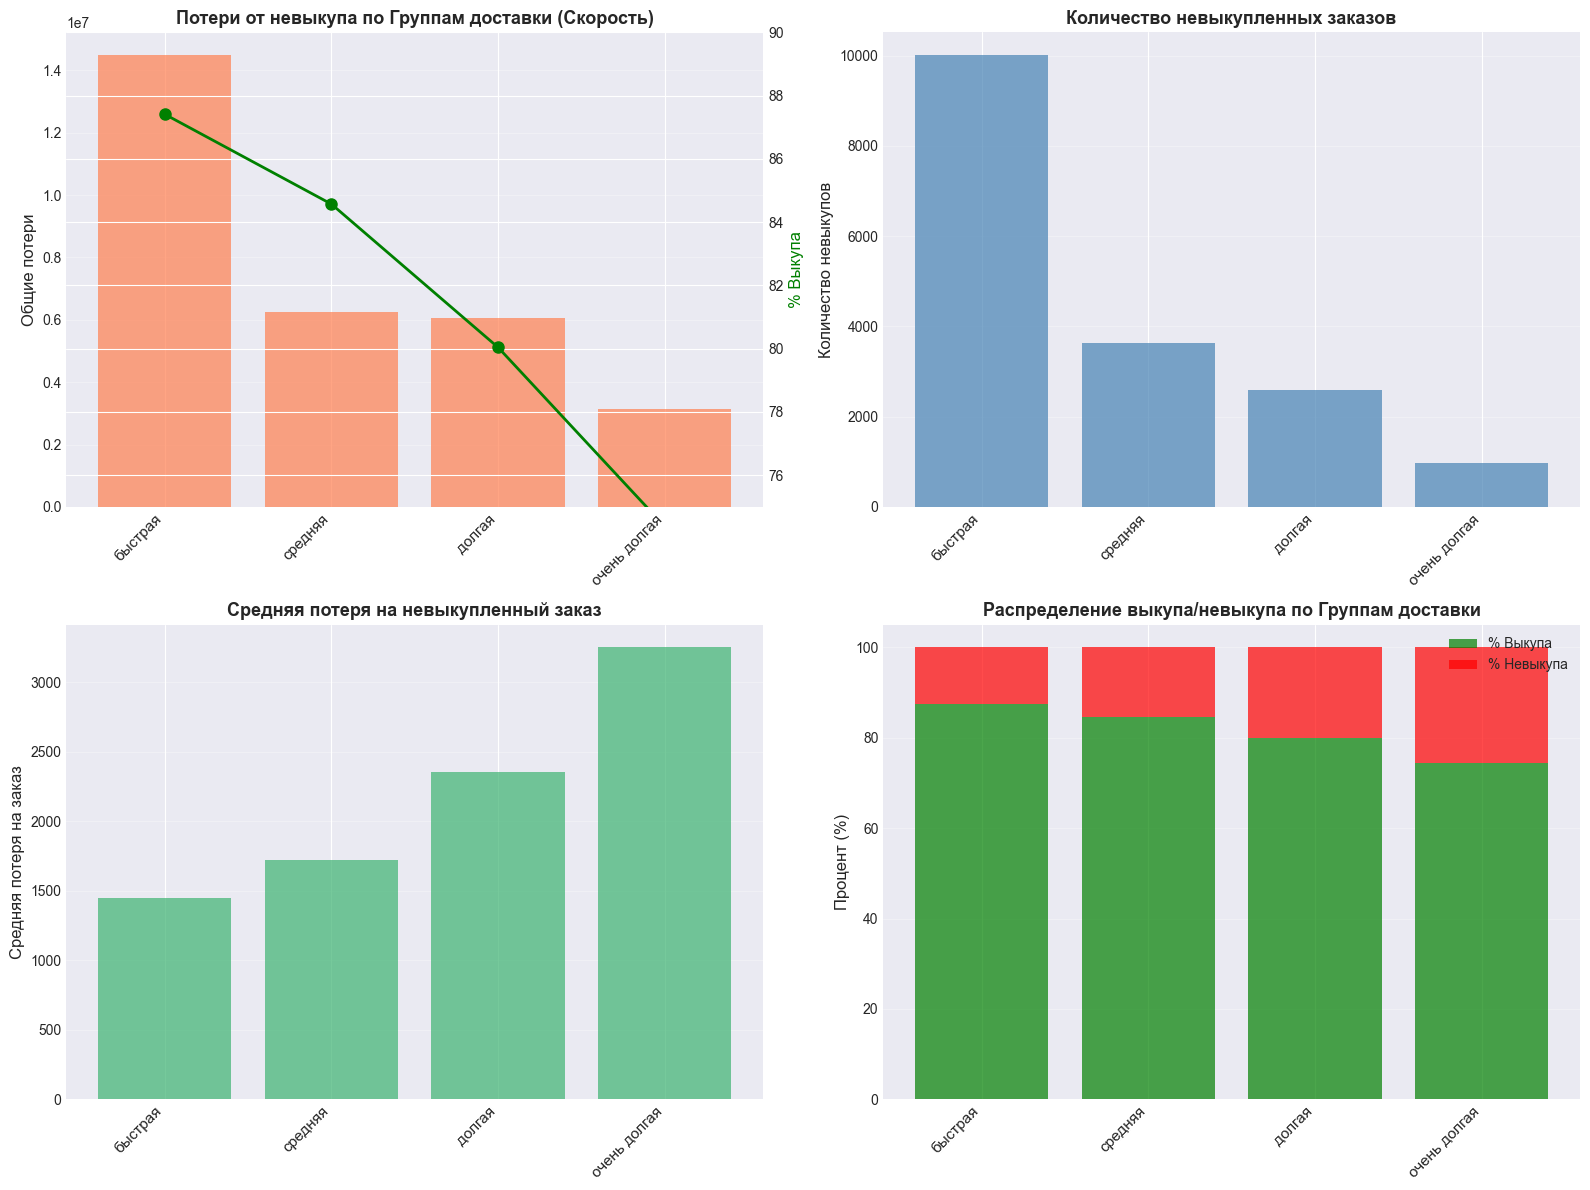

✓ График сохранён в './loss_analysis_results/08_loss_analysis_by_delivery_group.png'


In [ ]:
# Графики для Групп Доставки (Скорость доставки)
try:
    loss_by_delivery_group_sorted = loss_by_delivery_group.sort_values('Total Loss', ascending=False)
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # График 1: Потери по Группам доставки + % выкупа
    ax1 = axes[0, 0]
    ax1_twin = ax1.twinx()
    bars1 = ax1.bar(range(len(loss_by_delivery_group_sorted)), loss_by_delivery_group_sorted['Total Loss'], 
                   color='coral', alpha=0.7)
    line1 = ax1_twin.plot(range(len(loss_by_delivery_group_sorted)), loss_by_delivery_group_sorted['Buyout Rate %'], 
                         'go-', linewidth=2, markersize=8)
    ax1_twin.set_ylim(75, 90)
    ax1.set_xticks(range(len(loss_by_delivery_group_sorted)))
    ax1.set_xticklabels(loss_by_delivery_group_sorted.index, rotation=45, ha='right', fontsize=11)
    ax1.set_ylabel('Общие потери', fontsize=12)
    ax1_twin.set_ylabel('% Выкупа', fontsize=12, color='green')
    ax1.set_title('Потери от невыкупа по Группам доставки (Скорость)', fontweight='bold', fontsize=13)
    ax1.grid(axis='y', alpha=0.3)
    
    # График 2: Количество невыкупов
    ax2 = axes[0, 1]
    ax2.bar(range(len(loss_by_delivery_group_sorted)), loss_by_delivery_group_sorted['Non-buyout Orders'], 
           color='steelblue', alpha=0.7)
    ax2.set_xticks(range(len(loss_by_delivery_group_sorted)))
    ax2.set_xticklabels(loss_by_delivery_group_sorted.index, rotation=45, ha='right', fontsize=11)
    ax2.set_ylabel('Количество невыкупов', fontsize=12)
    ax2.set_title('Количество невыкупленных заказов', fontweight='bold', fontsize=13)
    ax2.grid(axis='y', alpha=0.3)
    
    # График 3: Средняя потеря
    ax3 = axes[1, 0]
    ax3.bar(range(len(loss_by_delivery_group_sorted)), loss_by_delivery_group_sorted['Avg Loss per Order'], 
           color='mediumseagreen', alpha=0.7)
    ax3.set_xticks(range(len(loss_by_delivery_group_sorted)))
    ax3.set_xticklabels(loss_by_delivery_group_sorted.index, rotation=45, ha='right', fontsize=11)
    ax3.set_ylabel('Средняя потеря на заказ', fontsize=12)
    ax3.set_title('Средняя потеря на невыкупленный заказ', fontweight='bold', fontsize=13)
    ax3.grid(axis='y', alpha=0.3)
    
    # График 4: Распределение выкупа/невыкупа
    ax4 = axes[1, 1]
    non_buyout_pct = 100 - loss_by_delivery_group_sorted['Buyout Rate %']
    x = range(len(loss_by_delivery_group_sorted))
    ax4.bar(x, loss_by_delivery_group_sorted['Buyout Rate %'], label='% Выкупа', color='green', alpha=0.7)
    ax4.bar(x, non_buyout_pct, bottom=loss_by_delivery_group_sorted['Buyout Rate %'], 
           label='% Невыкупа', color='red', alpha=0.7)
    ax4.set_xticks(range(len(loss_by_delivery_group_sorted)))
    ax4.set_xticklabels(loss_by_delivery_group_sorted.index, rotation=45, ha='right', fontsize=11)
    ax4.set_ylabel('Процент (%)', fontsize=12)
    ax4.set_title('Распределение выкупа/невыкупа по Группам доставки', fontweight='bold', fontsize=13)
    ax4.legend(fontsize=10)
    ax4.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'{results_folder}/08_loss_analysis_by_delivery_group.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✓ График сохранён в '{results_folder}/08_loss_analysis_by_delivery_group.png'")
except Exception as e:
    print(f"⚠️ Ошибка при создании графиков для Групп доставки: {e}")

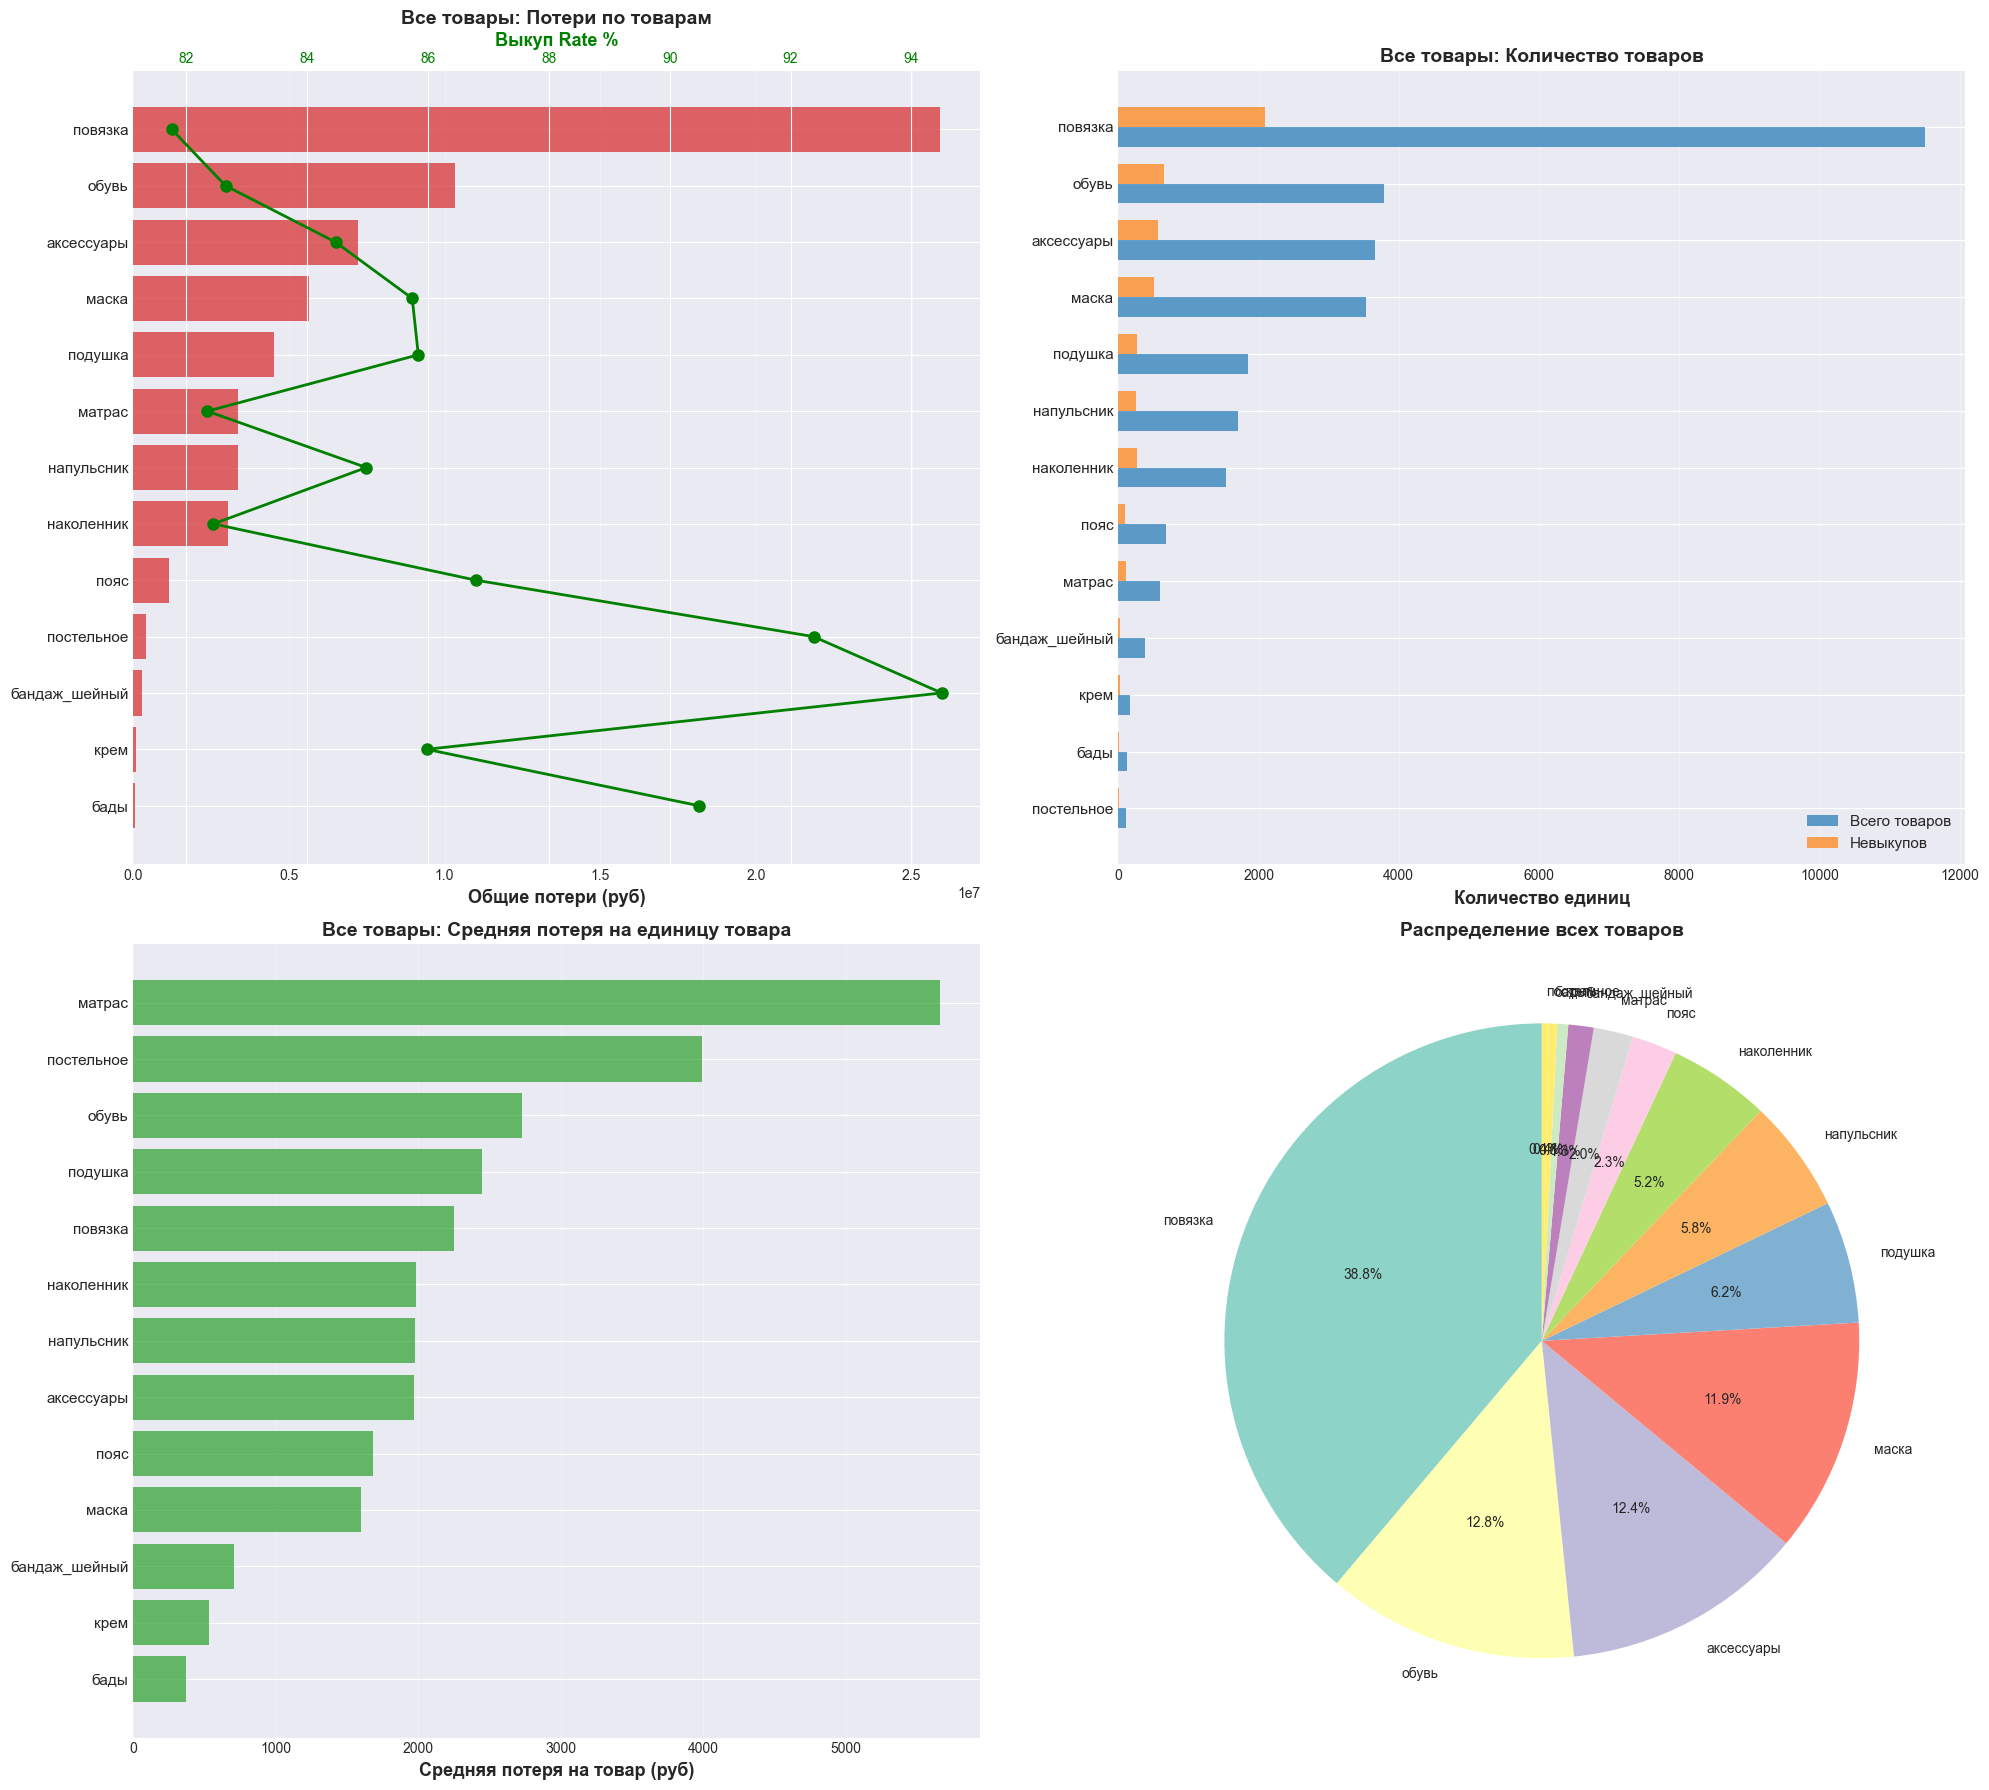

✓ График сохранён: 10_loss_analysis_by_products.png (все 13 товаров)


In [ ]:
# Визуализация анализа по товарам (все 13 товаров)
fig, axes = plt.subplots(2, 2, figsize=(20, 18))

# Отсортируем для графиков - без ограничения на топ 10
loss_by_product_sorted = loss_by_product.sort_values('Total Loss', ascending=True)

# 1. Потери + Выкуп %
ax1 = axes[0, 0]
bars1 = ax1.barh(range(len(loss_by_product_sorted)), loss_by_product_sorted['Total Loss'], 
                   color='#d62728', alpha=0.7, label='Потери (руб)')
ax1.set_yticks(range(len(loss_by_product_sorted)))
ax1.set_yticklabels(loss_by_product_sorted.index, fontsize=11)
ax1.set_xlabel('Общие потери (руб)', fontsize=13, fontweight='bold')
ax1.set_title('Все товары: Потери по товарам', fontsize=14, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

ax1_twin = ax1.twiny()
line1 = ax1_twin.plot(loss_by_product_sorted['Buyout Rate %'], range(len(loss_by_product_sorted)), 
                       'o-', color='green', linewidth=2, markersize=8, label='Выкуп %')
ax1_twin.set_xlabel('Выкуп Rate %', fontsize=13, fontweight='bold', color='green')
ax1_twin.tick_params(axis='x', labelcolor='green')

# 2. Количество товаров и невыкупов
ax2 = axes[0, 1]
loss_by_product_sorted2 = loss_by_product.sort_values('Total Items', ascending=True)
x_pos = np.arange(len(loss_by_product_sorted2))
width = 0.35
bars2 = ax2.barh(x_pos - width/2, loss_by_product_sorted2['Total Items'], width, 
                   label='Всего товаров', color='#1f77b4', alpha=0.7)
bars3 = ax2.barh(x_pos + width/2, loss_by_product_sorted2['Non-buyout Count'], width, 
                   label='Невыкупов', color='#ff7f0e', alpha=0.7)
ax2.set_yticks(x_pos)
ax2.set_yticklabels(loss_by_product_sorted2.index, fontsize=11)
ax2.set_xlabel('Количество единиц', fontsize=13, fontweight='bold')
ax2.set_title('Все товары: Количество товаров', fontsize=14, fontweight='bold')
ax2.legend(loc='lower right', fontsize=11)
ax2.grid(axis='x', alpha=0.3)

# 3. Средняя потеря на товар
ax3 = axes[1, 0]
loss_by_product_sorted3 = loss_by_product.sort_values('Avg Loss per Item', ascending=True)
bars4 = ax3.barh(range(len(loss_by_product_sorted3)), loss_by_product_sorted3['Avg Loss per Item'], 
                   color='#2ca02c', alpha=0.7)
ax3.set_yticks(range(len(loss_by_product_sorted3)))
ax3.set_yticklabels(loss_by_product_sorted3.index, fontsize=11)
ax3.set_xlabel('Средняя потеря на товар (руб)', fontsize=13, fontweight='bold')
ax3.set_title('Все товары: Средняя потеря на единицу товара', fontsize=14, fontweight='bold')
ax3.grid(axis='x', alpha=0.3)

# 4. Процентное распределение товаров
ax4 = axes[1, 1]
product_pct = (loss_by_product['Total Items'] / loss_by_product['Total Items'].sum() * 100).sort_values(ascending=False)
colors = plt.cm.Set3(range(len(product_pct)))
ax4.pie(product_pct, labels=product_pct.index, autopct='%1.1f%%', colors=colors, startangle=90, textprops={'fontsize': 10})
ax4.set_title('Распределение всех товаров', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{results_folder}/10_loss_analysis_by_products.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ График сохранён: 10_loss_analysis_by_products.png (все {len(loss_by_product)} товаров)")

## 12. Финансовый отчет и выводы

In [ ]:
# Финансовый отчет и выводы
print("="*80)
print("ФИНАНСОВЫЙ ОТЧЕТ: АНАЛИЗ ПОТЕРЬ ОТ НЕВЫКУПА ЗАКАЗОВ")
print("="*80)

print("\n📊 ОБЩАЯ СТАТИСТИКА:")
print("-" * 80)
total_orders = len(df)
non_buyout_orders = (df['buyout_flag'] == 0).sum()
non_buyout_rate = (non_buyout_orders / total_orders) * 100
total_loss = df['loss'].sum()
avg_loss_per_non_buyout = df[df['loss'] > 0]['loss'].mean()
avg_order_value = df['lead_price'].mean()
loss_percentage = (total_loss / df['lead_price'].sum()) * 100

print(f"• Всего заказов: {total_orders:,}")
print(f"• Невыкупленных заказов: {non_buyout_orders:,} ({non_buyout_rate:.2f}%)")
print(f"• Выкупленных заказов: {total_orders - non_buyout_orders:,} ({100 - non_buyout_rate:.2f}%)")
print(f"• ОБЩИЕ ПОТЕРИ: {total_loss:,.0f} руб.")
print(f"• Средняя потеря на невыкупленный заказ: {avg_loss_per_non_buyout:,.0f} руб.")
print(f"• Средняя стоимость заказа: {avg_order_value:,.0f} руб.")
print(f"• Потери как процент от общей стоимости: {loss_percentage:.2f}%")

print("\n🔴 ТОП-5 РЕГИОНОВ ПО ПОТЕРЯМ:")
print("-" * 80)
for idx, (region, row) in enumerate(loss_by_region.head().iterrows(), 1):
    print(f"{idx}. {region}")
    print(f"   └─ Потери: {row['Total Loss']:,.0f} руб. | Невыкупов: {int(row['Non-buyout Orders'])} | "
          f"% выкупа: {row['Buyout Rate %']:.2f}%")

print("\n💰 ТОП-5 ЦЕНОВЫХ ГРУПП ПО ПОТЕРЯМ:")
print("-" * 80)
for idx, (price_group, row) in enumerate(loss_by_price_group.head().iterrows(), 1):
    print(f"{idx}. {price_group}")
    print(f"   └─ Потери: {row['Total Loss']:,.0f} руб. | Невыкупов: {int(row['Non-buyout Orders'])} | "
          f"% выкупа: {row['Buyout Rate %']:.2f}%")

print("\n📦 ТОП-5 ГРУПП ДОСТАВКИ ПО ПОТЕРЯМ:")
print("-" * 80)
for idx, (delivery_group, row) in enumerate(loss_by_delivery_group.head().iterrows(), 1):
    print(f"{idx}. {delivery_group}")
    print(f"   └─ Потери: {row['Total Loss']:,.0f} руб. | Невыкупов: {int(row['Non-buyout Orders'])} | "
          f"% выкупа: {row['Buyout Rate %']:.2f}%")

# Найдем комбинацию с максимальными потерями
print("\n🎯 КРИТИЧЕСКИЕ КОМБИНАЦИИ (Регион + Цена + Доставка):")
print("-" * 80)
critical_combinations = df.groupby(['lead_region', 'price_group', 'delivery_group']).agg({
    'loss': ['sum', 'count']
}).round(2)
critical_combinations.columns = ['Total Loss', 'Non-buyout Orders']
critical_combinations = critical_combinations.sort_values('Total Loss', ascending=False)

for idx, ((region, price, delivery), row) in enumerate(critical_combinations.head(10).iterrows(), 1):
    print(f"{idx}. Регион: {region} | Цена: {price} | Доставка: {delivery}")
    print(f"   └─ Потери: {row['Total Loss']:,.0f} руб. | Невыкупов: {int(row['Non-buyout Orders'])}")

print("\n" + "="*80)

ФИНАНСОВЫЙ ОТЧЕТ: АНАЛИЗ ПОТЕРЬ ОТ НЕВЫКУПА ЗАКАЗОВ

📊 ОБЩАЯ СТАТИСТИКА:
--------------------------------------------------------------------------------
• Всего заказов: 17,966
• Невыкупленных заказов: 3,084 (17.17%)
• Выкупленных заказов: 14,882 (82.83%)
• ОБЩИЕ ПОТЕРИ: 35,952,479 руб.
• Средняя потеря на невыкупленный заказ: 11,742 руб.
• Средняя стоимость заказа: 11,554 руб.
• Потери как процент от общей стоимости: 17.32%

🔴 ТОП-5 РЕГИОНОВ ПО ПОТЕРЯМ:
--------------------------------------------------------------------------------
1. Москва
   └─ Потери: 3,814,128 руб. | Невыкупов: 2313 | % выкупа: 86.17%
2. Московская область
   └─ Потери: 2,048,045 руб. | Невыкупов: 1288 | % выкупа: 86.34%
3. Краснодарский край
   └─ Потери: 1,734,856 руб. | Невыкупов: 870 | % выкупа: 82.41%
4. Санкт-Петербург
   └─ Потери: 1,416,391 руб. | Невыкупов: 920 | % выкупа: 86.30%
5. Свердловская область
   └─ Потери: 1,355,227 руб. | Невыкупов: 591 | % выкупа: 81.73%

💰 ТОП-5 ЦЕНОВЫХ ГРУПП ПО ПОТЕРЯМ:


In [ ]:

# Дополнительный анализ новых полей
print("\n🆕 АНАЛИЗ ПО НОВЫМ КАТЕГОРИЯМ:")
print("-" * 80)

if 'loss_by_delivery_service' in locals():
    print("\n📦 ТОП-3 СЛУЖБ ДОСТАВКИ ПО ПОТЕРЯМ:")
    for idx, (service, row) in enumerate(loss_by_delivery_service.head(3).iterrows(), 1):
        print(f"{idx}. {service}: {row['Total Loss']:,.0f} руб. | "
              f"Выкуп: {row['Buyout Rate %']:.1f}% | Невыкупов: {int(row['Non-buyout Orders'])}")

if 'loss_by_payment_type' in locals():
    print("\n💳 ТОП-3 ВИДОВ ОПЛАТЫ ПО ПОТЕРЯМ:")
    for idx, (payment, row) in enumerate(loss_by_payment_type.head(3).iterrows(), 1):
        print(f"{idx}. {payment}: {row['Total Loss']:,.0f} руб. | "
              f"Выкуп: {row['Buyout Rate %']:.1f}% | Невыкупов: {int(row['Non-buyout Orders'])}")

if 'loss_by_delivery_tariff' in locals():
    print("\n💰 ТОП-3 ТАРИФОВ ДОСТАВКИ ПО ПОТЕРЯМ:")
    for idx, (tariff, row) in enumerate(loss_by_delivery_tariff.head(3).iterrows(), 1):
        print(f"{idx}. {tariff}: {row['Total Loss']:,.0f} руб. | "
              f"Выкуп: {row['Buyout Rate %']:.1f}% | Невыкупов: {int(row['Non-buyout Orders'])}")

if 'loss_by_product' in locals():
    print("\n💊 ТОП-3 ТОВАРОВ ПО ПОТЕРЯМ:")
    for idx, (product, row) in enumerate(loss_by_product.head(3).iterrows(), 1):
        print(f"{idx}. {product}: {row['Total Loss']:,.0f} руб. | "
              f"Выкуп: {row['Buyout Rate %']:.1f}% | Товаров: {int(row['Total Items'])} | "
              f"Потери/ед: {row['Loss per Non-buyout Item']:,.0f} руб.")


🆕 АНАЛИЗ ПО НОВЫМ КАТЕГОРИЯМ:
--------------------------------------------------------------------------------

📦 ТОП-3 СЛУЖБ ДОСТАВКИ ПО ПОТЕРЯМ:
1. СДЭК до ПВЗ: 21,852,112 руб. | Выкуп: 84.7% | Невыкупов: 12588
2. Почта: 7,902,308 руб. | Выкуп: 76.5% | Невыкупов: 2922
3. СДЭК до Двери: 6,118,918 руб. | Выкуп: 81.1% | Невыкупов: 2416

💳 ТОП-3 ВИДОВ ОПЛАТЫ ПО ПОТЕРЯМ:
1. Наложенный платеж: 35,605,757 руб. | Выкуп: 82.2% | Невыкупов: 17175
2. Оплата онлайн: 203,701 руб. | Выкуп: 97.6% | Невыкупов: 591
3. Оплата на карту: 68,381 руб. | Выкуп: 97.7% | Невыкупов: 174

💰 ТОП-3 ТАРИФОВ ДОСТАВКИ ПО ПОТЕРЯМ:
1. Посылка склад-склад: 23,579,676 руб. | Выкуп: 83.7% | Невыкупов: 12611
2. Посылка склад-дверь: 6,113,994 руб. | Выкуп: 80.5% | Невыкупов: 2303
3. Почта Посылка: 4,944,253 руб. | Выкуп: 77.0% | Невыкупов: 1763

💊 ТОП-3 ТОВАРОВ ПО ПОТЕРЯМ:
1. повязка: 25,905,968 руб. | Выкуп: 81.8% | Товаров: 11504 | Потери/ед: 12,348 руб.
2. обувь: 10,323,389 руб. | Выкуп: 82.7% | Товаров: 3787 | Потери

## 13. Экспорт результатов анализа

In [ ]:
# Экспорт результатов в CSV файлы для дальнейшего анализа

# 1. Потери по регионам
loss_by_region.to_csv(f'{results_folder}/loss_analysis_by_region.csv', encoding='utf-8-sig')
print("✓ loss_analysis_by_region.csv")

# 2. Потери по ценовым группам
loss_by_price_group.to_csv(f'{results_folder}/loss_analysis_by_price_group.csv', encoding='utf-8-sig')
print("✓ loss_analysis_by_price_group.csv")

# 3. Потери по группам доставки
loss_by_delivery_group.to_csv(f'{results_folder}/loss_analysis_by_delivery_group.csv', encoding='utf-8-sig')
print("✓ loss_analysis_by_delivery_group.csv")

# 4. Потери по Службе доставки
if 'loss_by_delivery_service' in locals():
    loss_by_delivery_service.to_csv(f'{results_folder}/loss_analysis_by_delivery_service.csv', encoding='utf-8-sig')
    print("✓ loss_analysis_by_delivery_service.csv")

# 5. Потери по Виду оплаты
if 'loss_by_payment_type' in locals():
    loss_by_payment_type.to_csv(f'{results_folder}/loss_analysis_by_payment_type.csv', encoding='utf-8-sig')
    print("✓ loss_analysis_by_payment_type.csv")

# 6. Потери по Тарифу Доставки
if 'loss_by_delivery_tariff' in locals():
    loss_by_delivery_tariff.to_csv(f'{results_folder}/loss_analysis_by_delivery_tariff.csv', encoding='utf-8-sig')
    print("✓ loss_analysis_by_delivery_tariff.csv")

# 7. Потери по товарам
if 'loss_by_product' in locals():
    loss_by_product.to_csv(f'{results_folder}/loss_analysis_by_products.csv', encoding='utf-8-sig')
    print("✓ loss_analysis_by_products.csv")

# 8. Комбинированный анализ (Регион + Цена + Доставка)
critical_combinations.to_csv(f'{results_folder}/loss_analysis_critical_combinations.csv', encoding='utf-8-sig')
print("✓ loss_analysis_critical_combinations.csv")

# 9. Пивот-таблица: Регион vs Ценовая группа
pivot_region_price.to_csv(f'{results_folder}/pivot_region_price_group.csv', encoding='utf-8-sig')
print("✓ pivot_region_price_group.csv")

# 10. Пивот-таблица: Регион vs Группа доставки
pivot_region_delivery.to_csv(f'{results_folder}/pivot_region_delivery_group.csv', encoding='utf-8-sig')
print("✓ pivot_region_delivery_group.csv")

# 11. Пивот-таблица: Ценовая группа vs Группа доставки
pivot_price_delivery.to_csv(f'{results_folder}/pivot_price_delivery_group.csv', encoding='utf-8-sig')
print("✓ pivot_price_delivery_group.csv")

# 12. Полный датасет с потерями
output_df = df[['lead_region', 'price_group', 'delivery_group', 'lead_price', 'buyout_flag', 'loss']].copy()
output_df.to_csv(f'{results_folder}/loss_analysis_full_data.csv', index=False, encoding='utf-8-sig')
print("✓ loss_analysis_full_data.csv")

print("\n✅ Все результаты успешно экспортированы!")

✓ loss_analysis_by_region.csv
✓ loss_analysis_by_price_group.csv
✓ loss_analysis_by_delivery_group.csv
✓ loss_analysis_by_delivery_service.csv
✓ loss_analysis_by_payment_type.csv
✓ loss_analysis_by_delivery_tariff.csv
✓ loss_analysis_by_products.csv
✓ loss_analysis_critical_combinations.csv
✓ pivot_region_price_group.csv
✓ pivot_region_delivery_group.csv
✓ pivot_price_delivery_group.csv
✓ loss_analysis_full_data.csv

✅ Все результаты успешно экспортированы!


In [ ]:
from PIL import Image
from PyPDF2 import PdfMerger
import glob

# Получаем все PNG файлы из папки, отсортированные по имени
png_files = sorted(glob.glob(f'{results_folder}/*.png'))

if png_files:
    print(f"Найдено {len(png_files)} PNG файлов")
    
    # Конвертируем PNG в PDF
    pdf_files = []
    for png_file in png_files:
        pdf_file = png_file.replace('.png', '_temp.pdf')
        
        # Открываем PNG и конвертируем в PDF
        img = Image.open(png_file).convert('RGB')
        img.save(pdf_file)
        pdf_files.append(pdf_file)
        print(f"✓ Конвертирован: {os.path.basename(png_file)} -> PDF")
    
    # Объединяем все PDF в один
    if pdf_files:
        merger = PdfMerger()
        for pdf_file in pdf_files:
            merger.append(pdf_file)
        
        # Сохраняем объединенный PDF
        output_pdf = f'{results_folder}/loss_analysis_all_charts.pdf'
        merger.write(output_pdf)
        merger.close()
        
        # Удаляем временные PDF файлы
        for pdf_file in pdf_files:
            os.remove(pdf_file)
        
        print(f"\n✅ Все графики объединены в: {output_pdf}")
        print(f"   Размер файла: {os.path.getsize(output_pdf) / (1024*1024):.2f} МБ")
else:
    print("⚠️ PNG файлы не найдены")

Найдено 11 PNG файлов
✓ Конвертирован: 01_loss_analysis_by_region.png -> PDF
✓ Конвертирован: 02_loss_analysis_by_price_delivery.png -> PDF
✓ Конвертирован: 03_heatmap_region_price.png -> PDF
✓ Конвертирован: 03_loss_distribution_pie_charts.png -> PDF
✓ Конвертирован: 04_loss_distribution_histogram.png -> PDF
✓ Конвертирован: 05_loss_distribution_pie_charts.png -> PDF
✓ Конвертирован: 06_loss_analysis_by_delivery_service.png -> PDF
✓ Конвертирован: 07_loss_analysis_by_payment_type.png -> PDF
✓ Конвертирован: 08_loss_analysis_by_delivery_group.png -> PDF
✓ Конвертирован: 09_loss_analysis_by_delivery_tariff.png -> PDF
✓ Конвертирован: 10_loss_analysis_by_products.png -> PDF

✅ Все графики объединены в: ./loss_analysis_results/loss_analysis_all_charts.pdf
   Размер файла: 7.00 МБ


## 14. Объединение всех графиков в один PDF файл

## 14. Рекомендации по снижению потерь

In [ ]:
# Анализ рекомендаций для снижения потерь
print("="*80)
print("РЕКОМЕНДАЦИИ ДЛЯ ФИНАНСОВОГО АНАЛИЗА И СНИЖЕНИЯ ПОТЕРЬ")
print("="*80)

# Добавляем колонку Non-buyout % для анализа
loss_by_region_analysis = loss_by_region.copy()
loss_by_region_analysis['Non-buyout %'] = 100 - loss_by_region_analysis['Buyout Rate %']

loss_by_price_group_analysis = loss_by_price_group.copy()
loss_by_price_group_analysis['Non-buyout %'] = 100 - loss_by_price_group_analysis['Buyout Rate %']

loss_by_delivery_group_analysis = loss_by_delivery_group.copy()
loss_by_delivery_group_analysis['Non-buyout %'] = 100 - loss_by_delivery_group_analysis['Buyout Rate %']

# Идентифицируем проблемные области
high_loss_regions = loss_by_region_analysis[loss_by_region_analysis['Non-buyout %'] > loss_by_region_analysis['Non-buyout %'].median()]
print("\n🔴 РЕГИОНЫ С ПОВЫШЕННЫМ ПРОЦЕНТОМ НЕВЫКУПА:")
print("-" * 80)
for region, row in high_loss_regions.iterrows():
    print(f"• {region}: {row['Non-buyout %']:.2f}% невыкупа → {row['Total Loss']:,.0f} руб. потерь")
    print(f"  Рекомендация: Усилить маркетинг, проверить логистику, улучшить контроль качества")

high_loss_price = loss_by_price_group_analysis[loss_by_price_group_analysis['Non-buyout %'] > loss_by_price_group_analysis['Non-buyout %'].median()]
print("\n💰 ЦЕНОВЫЕ ГРУППЫ С ВЫСОКИМИ ПОТЕРЯМИ:")
print("-" * 80)
for price_group, row in high_loss_price.iterrows():
    print(f"• {price_group}: {row['Non-buyout %']:.2f}% невыкупа → {row['Total Loss']:,.0f} руб. потерь")
    print(f"  Рекомендация: Пересмотреть цены, улучшить описание товаров, рассмотреть скидки")

high_loss_delivery = loss_by_delivery_group_analysis[loss_by_delivery_group_analysis['Non-buyout %'] > loss_by_delivery_group_analysis['Non-buyout %'].median()]
print("\n📦 ГРУППЫ ДОСТАВКИ С ВЫСОКИМИ ПОТЕРЯМИ:")
print("-" * 80)
for delivery_group, row in high_loss_delivery.iterrows():
    print(f"• {delivery_group}: {row['Non-buyout %']:.2f}% невыкупа → {row['Total Loss']:,.0f} руб. потерь")
    print(f"  Рекомендация: Улучшить сроки доставки, снизить стоимость, проверить надежность")

# Потенциальная экономия
print("\n💡 ПОТЕНЦИАЛЬНАЯ ЭКОНОМИЯ:")
print("-" * 80)
achievable_improvement = 0.3  # Предположим, что можно улучшить на 30%
potential_savings = total_loss * achievable_improvement
current_rate = non_buyout_rate
target_rate = current_rate * (1 - achievable_improvement)

print(f"• Текущий уровень невыкупа: {non_buyout_rate:.2f}%")
print(f"• Целевой уровень (при 30% улучшении): {target_rate:.2f}%")

РЕКОМЕНДАЦИИ ДЛЯ ФИНАНСОВОГО АНАЛИЗА И СНИЖЕНИЯ ПОТЕРЬ

🔴 РЕГИОНЫ С ПОВЫШЕННЫМ ПРОЦЕНТОМ НЕВЫКУПА:
--------------------------------------------------------------------------------
• Свердловская область: 18.27% невыкупа → 1,355,227 руб. потерь
  Рекомендация: Усилить маркетинг, проверить логистику, улучшить контроль качества
• Ростовская область: 19.72% невыкупа → 945,102 руб. потерь
  Рекомендация: Усилить маркетинг, проверить логистику, улучшить контроль качества
• Челябинская область: 19.90% невыкупа → 886,751 руб. потерь
  Рекомендация: Усилить маркетинг, проверить логистику, улучшить контроль качества
• Красноярский край: 19.47% невыкупа → 886,022 руб. потерь
  Рекомендация: Усилить маркетинг, проверить логистику, улучшить контроль качества
• Иркутская область: 21.23% невыкупа → 819,974 руб. потерь
  Рекомендация: Усилить маркетинг, проверить логистику, улучшить контроль качества
• Башкортостан: 20.45% невыкупа → 754,416 руб. потерь
  Рекомендация: Усилить маркетинг, проверить лог

In [ ]:
# Итоговая информация о структуре результатов
print("="*80)
print("📂 СТРУКТУРА РЕЗУЛЬТАТОВ АНАЛИЗА")
print("="*80)
print(f"\nПапка с результатами: {results_folder}/\n")

# Список всех файлов в папке
result_files = sorted(os.listdir(results_folder))

print("📊 СОДЕРЖАНИЕ ПАПКИ:")
print("-" * 80)

pdf_files = [f for f in result_files if f.endswith('.pdf')]
csv_files = [f for f in result_files if f.endswith('.csv')]
png_files = [f for f in result_files if f.endswith('.png')]

print(f"\n🔴 PDF файлы ({len(pdf_files)}):")
for f in pdf_files:
    size = os.path.getsize(os.path.join(results_folder, f)) / (1024*1024)
    print(f"  • {f} ({size:.2f} МБ)")

print(f"\n🟢 PNG файлы ({len(png_files)}):")
for f in png_files:
    size = os.path.getsize(os.path.join(results_folder, f)) / 1024
    print(f"  • {f} ({size:.1f} КБ)")

print(f"\n🔵 CSV файлы ({len(csv_files)}):")
for f in csv_files:
    size = os.path.getsize(os.path.join(results_folder, f)) / 1024
    print(f"  • {f} ({size:.1f} КБ)")

print("\n" + "="*80)
print("✅ АНАЛИЗ ЗАВЕРШЕН!")
print("="*80)
print("\n📋 ОПИСАНИЕ ФАЙЛОВ:")
print("-" * 80)
print("""
PDF-отчёт:
  • loss_analysis_all_charts.pdf - Все графики в одном файле

Основные графики (PNG):
  • 01_loss_analysis_by_region.png - Потери по регионам (4 графика с % выкупа)
  • 02_loss_analysis_by_price_delivery.png - Потери по ценам и доставке (4 графика)
  • 03_heatmap_region_price.png - Тепловые карты (3 части по объему заказов)
  • 04_loss_distribution_histogram.png - Гистограмма распределения потерь
  • 05_loss_distribution_pie_charts.png - Круговые диаграммы распределения

Таблицы по основным категориям (CSV):
  • loss_analysis_by_region.csv - Потери по регионам (с % выкупа)
  • loss_analysis_by_price_group.csv - Потери по ценовым группам (с % выкупа)
  • loss_analysis_by_delivery_group.csv - Потери по группам доставки (с % выкупа)
  • loss_analysis_by_delivery_service.csv - Потери по Службе доставки
  • loss_analysis_by_payment_type.csv - Потери по Виду оплаты
  • loss_analysis_by_mop_payment.csv - Потери по Оплате МОП
  • loss_analysis_by_delivery_tariff.csv - Потери по Тарифу Доставки

Матрицы комбинированного анализа (CSV):
  • loss_analysis_critical_combinations.csv - Топ комбинации (Регион × Цена × Доставка)
  • pivot_region_price_group.csv - Матрица Регион × Ценовая группа
  • pivot_region_delivery_group.csv - Матрица Регион × Группа доставки
  • pivot_price_delivery_group.csv - Матрица Ценовая группа × Группа доставки
  • loss_analysis_full_data.csv - Полный набор данных с потерями
""")
print("="*80)

📂 СТРУКТУРА РЕЗУЛЬТАТОВ АНАЛИЗА

Папка с результатами: ./loss_analysis_results/

📊 СОДЕРЖАНИЕ ПАПКИ:
--------------------------------------------------------------------------------

🔴 PDF файлы (1):
  • loss_analysis_all_charts.pdf (5.76 МБ)

🟢 PNG файлы (10):
  • 01_loss_analysis_by_region.png (543.4 КБ)
  • 02_loss_analysis_by_price_delivery.png (329.7 КБ)
  • 03_heatmap_region_price.png (1705.0 КБ)
  • 03_loss_distribution_pie_charts.png (387.7 КБ)
  • 04_loss_distribution_histogram.png (144.5 КБ)
  • 05_loss_distribution_pie_charts.png (387.7 КБ)
  • 06_loss_analysis_by_delivery_service.png (303.4 КБ)
  • 07_loss_analysis_by_payment_type.png (439.1 КБ)
  • 08_loss_analysis_by_mop_payment.png (290.2 КБ)
  • 09_loss_analysis_by_delivery_tariff.png (390.5 КБ)

🔵 CSV файлы (12):
  • loss_analysis_by_delivery_group.csv (0.3 КБ)
  • loss_analysis_by_delivery_service.csv (0.4 КБ)
  • loss_analysis_by_delivery_tariff.csv (0.8 КБ)
  • loss_analysis_by_mop_payment.csv (0.2 КБ)
  • loss_anal

## 16. Итовая информация о структуре результатов